## Cuped/Multicuped для снижения дисперсии в АБ экспериментах

# Математический пайплайн A/B-тестирования

## 1. Формулирование гипотез

В классическом A/B-тесте мы сравниваем средние значения целевой метрики (например, конверсии или среднего чека) в контрольной (A) и тестовой (B) группах.

*   **Нулевая гипотеза ($H_0$):** Разницы между группами нет.
*   **Альтернативная гипотеза ($H_1$):** Разница существует (двусторонняя гипотеза).

$$ H_0: \mu_A = \mu_B \quad \text{vs} \quad H_1: \mu_A \neq \mu_B $$

---

## 2. Расчет необходимого размера выборки ($n$) — Боттлнек A/B-тестов

Перед запуском эксперимента необходимо понять, сколько пользователей нам нужно собрать, чтобы зафиксировать желаемый эффект с заданными вероятностями ошибок первого ($\alpha$) и второго ($\beta$) рода.

Формула расчета объема выборки для одной группы (при условии $n_A = n_B = n$):

$$ n \approx \frac{(Z_{1-\alpha/2} + Z_{1-\beta})^2 \cdot (\sigma_A^2 + \sigma_B^2)}{\text{MDE}^2} $$

Где:
*   $\alpha$ — уровень значимости (обычно $0.05$, тогда $Z_{0.975} \approx 1.96$).
*   $1-\beta$ — статистическая мощность (обычно $0.80$, тогда $Z_{0.80} \approx 0.84$).
*   $\sigma_A^2, \sigma_B^2$ — дисперсии метрики в группах.
*   $\text{MDE} = |\mu_B - \mu_A|$ — Minimum Detectable Effect (минимально обнаруживаемый эффект).

### Почему размер выборки ($n$) — это главный боттлнек (узкое горлышко)?
Из формулы выше видно две критические зависимости:
1.  **Квадратичная зависимость от MDE:** $n \propto \frac{1}{\text{MDE}^2}$. Если бизнес хочет детектировать эффект в 2 раза меньше (например, рост не на 2%, а на 1%), размер выборки увеличится в **4 раза**. Мы физически можем не собрать столько трафика за адекватное время.
2.  **Прямая зависимость от дисперсии:** $n \propto \sigma^2$. Высокая дисперсия метрик (особенно денежных) раздувает требуемое количество пользователей до небес.

> **Связь с CUPED:** Именно этот боттлнек решает метод CUPED. Он математически уменьшает числитель ($\sigma^2$), что позволяет пропорционально сократить время проведения теста или детектировать меньший MDE при том же количестве пользователей.

---

## 3. Оценка результатов: t-критерий Уэлча (Welch's t-test)

После сбора данных мы проверяем гипотезы. В реальном бизнесе дисперсии в тестовой и контрольной группах редко бывают равны ($\sigma_A^2 \neq \sigma_B^2$), а размеры групп могут отличаться из-за дисбаланса сплитовалки ($n_A \neq n_B$).

Поэтому классический t-критерий Стьюдента применять некорректно. Используется его робастная модификация — **t-критерий Уэлча**.

### Формула t-статистики:

$$ t = \frac{\bar{X}_B - \bar{X}_A}{\sqrt{\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}}} $$

Где:
*   $\bar{X}_A, \bar{X}_B$ — выборочные средние.
*   $s_A^2, s_B^2$ — выборочные дисперсии.
*   $n_A, n_B$ — размеры выборок.


## 4. Правило принятия решения

Мы сравниваем полученное значение $|t|$ с критическим значением $t_{crit}$ из распределения Стьюдента с $\nu$ степенями свободы, либо вычисляем p-value:

$$ p\text{-value} = 2 \cdot (1 - F_{t(\nu)}(|t|)) $$

*   Если $p\text{-value} < \alpha$ — мы **отвергаем нулевую гипотезу** $H_0$. Эффект от внедрения статистически значим.
*   Если $p\text{-value} \ge \alpha$ — у нас недостаточно оснований отвергнуть $H_0$. Разница может быть случайной.

статься на валидность мульти купеда https://habr.com/ru/companies/X5Tech/articles/846298/   через линейную регрессию ковариат и страт без ортогонализации



## CUPED (Controlled Experiments Using Pre-Experiment Data)

Цель CUPED — снизить дисперсию целевой метрики (таргета) $Y$, используя данные до начала эксперимента (ковариату $X$). Это позволяет повысить чувствительность A/B-теста (увеличить мощность) и быстрее достичь статистической значимости без увеличения выборки.

Пусть $Y$ — целевая метрика пользователя в период теста, а $X$ — его метрика до теста (ковариата). Мы конструируем новую метрику $Y_{cuped}$:

$$ Y_{cuped} = Y - \theta (X - \mathbb{E}[X]) $$

Где $\theta$ — некоторая константа, а $\mathbb{E}[X]$ — математическое ожидание ковариаты (на практике заменяется выборочным средним $\bar{X}$).

**1. Несмещенность (Unbiasedness):**
Поскольку математическое ожидание константы равно самой константе, а $\mathbb{E}[X - \mathbb{E}[X]] = 0$, среднее значение новой метрики совпадает со средним оригинальной:
$$ \mathbb{E}[Y_{cuped}] = \mathbb{E}[Y] - \theta(\mathbb{E}[X] - \mathbb{E}[X]) = \mathbb{E}[Y] $$

**2. Снижение дисперсии (Variance Reduction):**
Вычислим дисперсию новой метрики:
$$ \text{Var}(Y_{cuped}) = \text{Var}(Y - \theta X) = \text{Var}(Y) + \theta^2 \text{Var}(X) - 2\theta \text{Cov}(Y, X) $$

Чтобы дисперсия была минимальной, найдем производную по $\theta$ и приравняем к нулю:
$$ \frac{\partial \text{Var}(Y_{cuped})}{\partial \theta} = 2\theta \text{Var}(X) - 2\text{Cov}(Y, X) = 0 $$

Отсюда получаем **оптимальное значение тета ($\theta^*$)**:
$$ \theta^* = \frac{\text{Cov}(Y, X)}{\text{Var}(X)} $$

Подставив $\theta^*$ обратно в формулу дисперсии, получим:
$$ \text{Var}(Y_{cuped}) = \text{Var}(Y) - \frac{\text{Cov}(Y, X)^2}{\text{Var}(X)} = \text{Var}(Y) \left( 1 - \rho_{X,Y}^2 \right) $$

Где $\rho_{X,Y}$ — коэффициент корреляции Пирсона между $X$ и $Y$. Таким образом, **чем выше корреляция ковариаты с таргетом, тем сильнее снижается дисперсия**.

# Чистый кьюпед для всех таргетов


## 1. Classic Single CUPED (Обычный CUPED с одной ковариатой)

В данном подходе мы используем только один признак из множества доступных ковариат $\mathcal{X} = \{X_1, X_2, \dots, X_p\}$.

**Шаг 1. Выбор лучшей ковариаты:**
Алгоритм вычисляет модуль корреляции Пирсона для каждого признака с таргетом и выбирает признак $X_{best}$ с максимальным значением:
$$ X_{best} = \arg\max_{X_k \in \mathcal{X}} \left| \rho(Y, X_k) \right| $$

**Шаг 2. Вычисление метрики:**
Для выбранного $X_{best}$ вычисляется классический CUPED:
$$ \theta = \frac{\text{Cov}(Y, X_{best})}{\text{Var}(X_{best})} $$
$$ Y_{cuped}^{(i)} = Y^{(i)} - \theta (X_{best}^{(i)} - \bar{X}_{best}) $$

In [ ]:
df_ = pd.read_csv(DATA_PATH)
df_.head(10)

,nfu_flg,orig_cost_sum,life_1_day_flg,life_32_day_flg,channel_desc,flow_strategy_code,pdt,el,ms,cs,...,app_xsell_total_sale_flg,email_cnt_all,email_cnt_1,email_open_flg_sum,email_open_flg_sum_1,email_delivery_flg_sum,email_delivery_flg_sum_1,email_click_cnt_sum,email_click_cnt_sum_1,email_open_to_delivery_sum_ratio
0,1,0.00,0,0,МБ,NCD,0,-1,-1,0,...,0,19,11,0,0,7,3,0,0,0.000000
1,0,0.00,0,0,МБ,DAC,0,-1,-1,0,...,1,119,19,2,1,119,19,0,0,0.016807
2,1,0.00,0,0,МБ,DAC,0,0,1,0,...,0,6,1,5,1,6,1,0,0,0.833333
3,0,0.00,1,1,МБ,DAC,0,3,0,0,...,0,1,0,0,0,0,0,0,0,0.000000
4,0,1021.11,0,0,Web,FST,0,-1,-1,0,...,0,3,3,0,0,3,3,0,0,0.000000
5,1,0.00,0,0,МБ,DAC,0,-1,-1,0,...,0,60,0,4,0,34,0,0,0,0.117647
6,0,1073.20,1,1,Web,DAC,0,-1,-1,0,...,0,107,12,0,0,107,12,0,0,0.000000
7,0,257.00,0,0,МБ,DAC,0,-1,-1,0,...,0,144,29,4,0,144,29,0,0,0.027778
8,0,0.00,1,0,МБ,DAC,0,3,0,0,...,0,120,18,11,1,120,18,0,0,0.091667
9,1,0.00,0,0,Web,FST,0,-1,-1,0,...,0,3,3,1,1,3,3,0,0,0.333333


In [ ]:
df_.shape

(83208, 357)

задача найти лучшую/лучшие ковариаты для использования CUPED, когда в качестве целевой метрики мы используем life_1_day_flg, orig_cost_sum, life_32_day_flg.

Аналитикой заявок на премиум карты.
Одна из основных метрик - доля полезных подключений (life_1_day_flg). Полезные подключения: клиент был на подписке Premium 1 день или более.
Также есть метрика: доля людей, которые были на подписке 32 дня и более (life_32_day_flg).
И средний кост: наши затраты на клиента (orig_cost_sum)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ==========================================
# 1. ЗАГРУЗКА И ОЧИСТКА ДАННЫХ
# ==========================================
def load_and_clean_data(filepath, target_col, other_targets):
    print(f"[{target_col}] Загрузка и очистка данных...")
    df = pd.read_csv(filepath)
    df = df.replace(-1, 0).fillna(0)

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df = df[numeric_cols]

    # Исключение других таргетов (Target Leakage)
    drop_targets = [c for c in other_targets if c in df.columns]
    if drop_targets:
        df = df.drop(columns=drop_targets)
        print(f"Удалены другие таргеты: {drop_targets}")

    # Константные признаки
    const_cols = [c for c in df.columns if df[c].nunique() <= 1]
    if const_cols:
        df = df.drop(columns=const_cols)

    # Редкие бинарки (< 100 наблюдений)
    rare_cols = [c for c in df.columns if df[c].nunique() == 2 and df[c].value_counts().min() < 100]
    if rare_cols:
        df = df.drop(columns=rare_cols)

    print(f"Итоговый размер датасета: {df.shape}\n")
    return df


# ==========================================
# 2. CLASSIC SINGLE CUPED (ОДНА КОВАРИАТА)
# ==========================================
def apply_single_cuped(df, target_col):
    print(f"Шаг 2. Запуск Classic Single CUPED для метрики: {target_col}")

    cuped_col = f"{target_col}_cuped"
    df[cuped_col] = df[target_col].astype(float)

    excluded_features = {target_col, cuped_col}
    potential_covs = [c for c in df.columns if c not in excluded_features]

    y_real = df[target_col].values

    # 1. Ищем ОДНУ ЛУЧШУЮ ковариату (максимальная корреляция)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        correlations = df[potential_covs].corrwith(pd.Series(y_real)).abs().dropna()

    best_covariate = correlations.idxmax()
    max_corr = correlations.max()
    print(f"  -> Найдена лучшая ковариата: '{best_covariate}' (Корреляция с таргетом: {max_corr:.4f})")

    # 2. Извлекаем этот признак
    x_covariate = df[best_covariate].values

    # 3. Вычисление классической Theta
    cov_matrix = np.cov(y_real, x_covariate)
    var_x = cov_matrix[1, 1]

    if var_x > 0:
        theta = cov_matrix[0, 1] / var_x
    else:
        theta = 0

    # 4. КЛАССИЧЕСКАЯ ФОРМУЛА SINGLE CUPED
    y_cuped = y_real - theta * (x_covariate - np.mean(x_covariate))
    df[cuped_col] = y_cuped

    # Статистика
    var_before = np.var(y_real)
    var_after = np.var(y_cuped)
    reduction = 1 - (var_after / var_before) if var_before > 0 else 0

    print("\n" + "="*50)
    print(f"РЕЗУЛЬТАТЫ SINGLE CUPED: {target_col}")
    print("="*50)
    print(f"Выбранная ковариата (X):  {best_covariate}")
    print(f"Оптимальная Theta (\u03B8):    {theta:.4f}")
    print(f"Общая дисперсия ДО:       {var_before:.2f}")
    print(f"Общая дисперсия ПОСЛЕ:    {var_after:.2f}")
    print(f"ОБЩЕЕ СНИЖЕНИЕ VAR:       {reduction * 100:.2f}%")
    print("="*50)

    # ВОЗВРАЩАЕМ df И ИМЯ ЛУЧШЕЙ КОВАРИАТЫ ДЛЯ ГРАФИКА
    return df, best_covariate


In [ ]:
# ==========================================
# ЗАПУСК PIPELINE ДЛЯ ВСЕХ МЕТРИК СРАЗУ
# ==========================================
DATA_PATH = '/content/drive/MyDrive/курсач/dataset_back.csv'
ALL_MY_TARGETS = ['orig_cost_sum', 'life_1_day_flg', 'life_32_day_flg']



######################################################################
### АНАЛИЗ МЕТРИКИ: orig_cost_sum
######################################################################
[orig_cost_sum] Загрузка и очистка данных...
Удалены другие таргеты: ['life_1_day_flg', 'life_32_day_flg']
Итоговый размер датасета: (83208, 327)

Шаг 2. Запуск Classic Single CUPED для метрики: orig_cost_sum
  -> Найдена лучшая ковариата: 'attrition_score' (Корреляция с таргетом: 0.2053)

РЕЗУЛЬТАТЫ SINGLE CUPED: orig_cost_sum
Выбранная ковариата (X):  attrition_score
Оптимальная Theta (θ):    410.9449
Общая дисперсия ДО:       131554.08
Общая дисперсия ПОСЛЕ:    126007.93
ОБЩЕЕ СНИЖЕНИЕ VAR:       4.22%


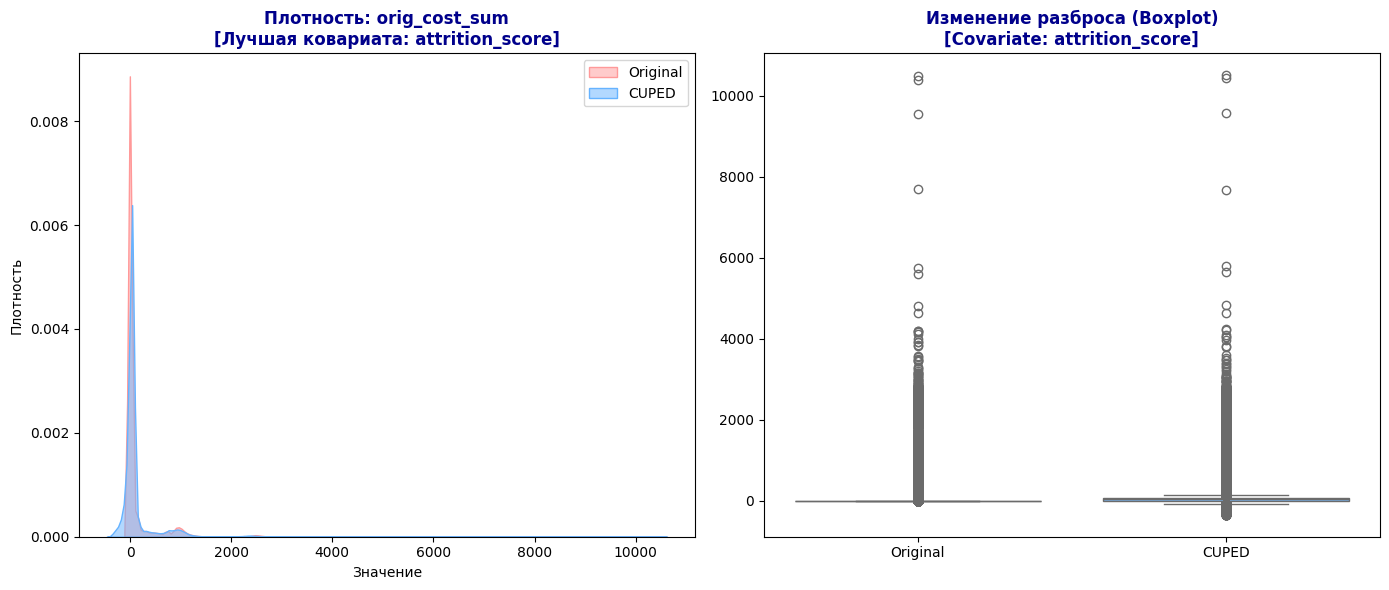


######################################################################
### АНАЛИЗ МЕТРИКИ: life_1_day_flg
######################################################################
[life_1_day_flg] Загрузка и очистка данных...
Удалены другие таргеты: ['orig_cost_sum', 'life_32_day_flg']
Итоговый размер датасета: (83208, 327)

Шаг 2. Запуск Classic Single CUPED для метрики: life_1_day_flg
  -> Найдена лучшая ковариата: 'attrition_score' (Корреляция с таргетом: 0.2967)

РЕЗУЛЬТАТЫ SINGLE CUPED: life_1_day_flg
Выбранная ковариата (X):  attrition_score
Оптимальная Theta (θ):    0.6613
Общая дисперсия ДО:       0.16
Общая дисперсия ПОСЛЕ:    0.15
ОБЩЕЕ СНИЖЕНИЕ VAR:       8.80%


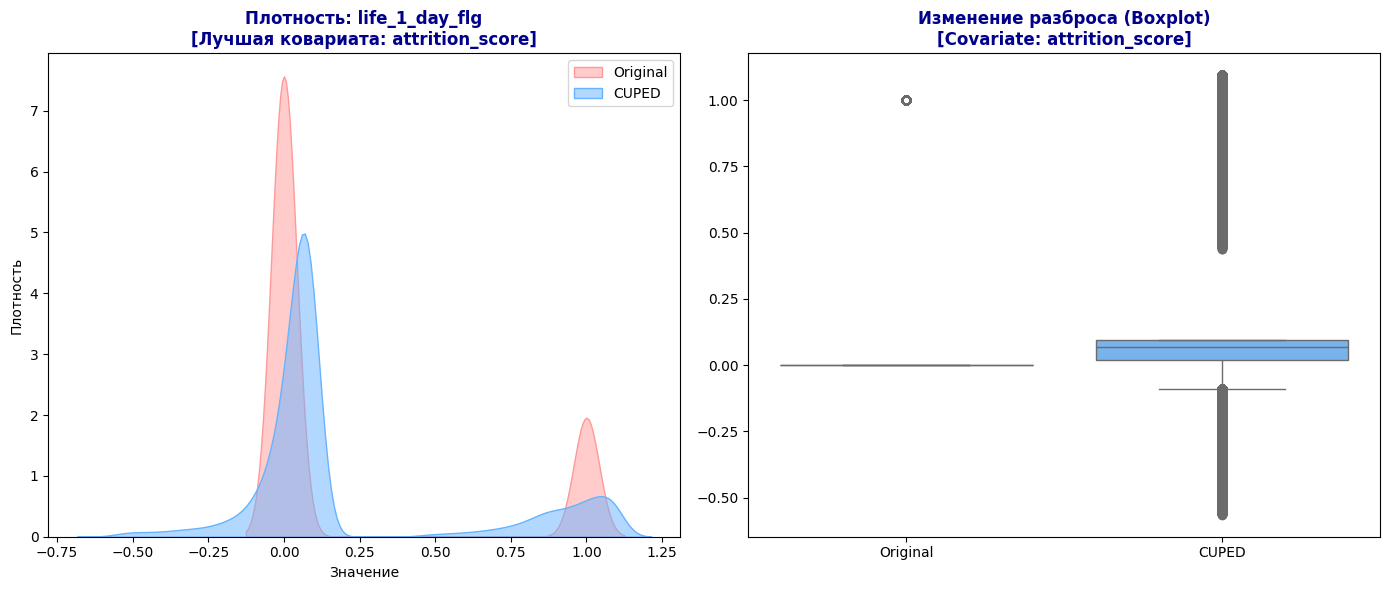


######################################################################
### АНАЛИЗ МЕТРИКИ: life_32_day_flg
######################################################################
[life_32_day_flg] Загрузка и очистка данных...
Удалены другие таргеты: ['orig_cost_sum', 'life_1_day_flg']
Итоговый размер датасета: (83208, 327)

Шаг 2. Запуск Classic Single CUPED для метрики: life_32_day_flg
  -> Найдена лучшая ковариата: 'attrition_score' (Корреляция с таргетом: 0.3353)

РЕЗУЛЬТАТЫ SINGLE CUPED: life_32_day_flg
Выбранная ковариата (X):  attrition_score
Оптимальная Theta (θ):    0.5101
Общая дисперсия ДО:       0.08
Общая дисперсия ПОСЛЕ:    0.07
ОБЩЕЕ СНИЖЕНИЕ VAR:       11.24%


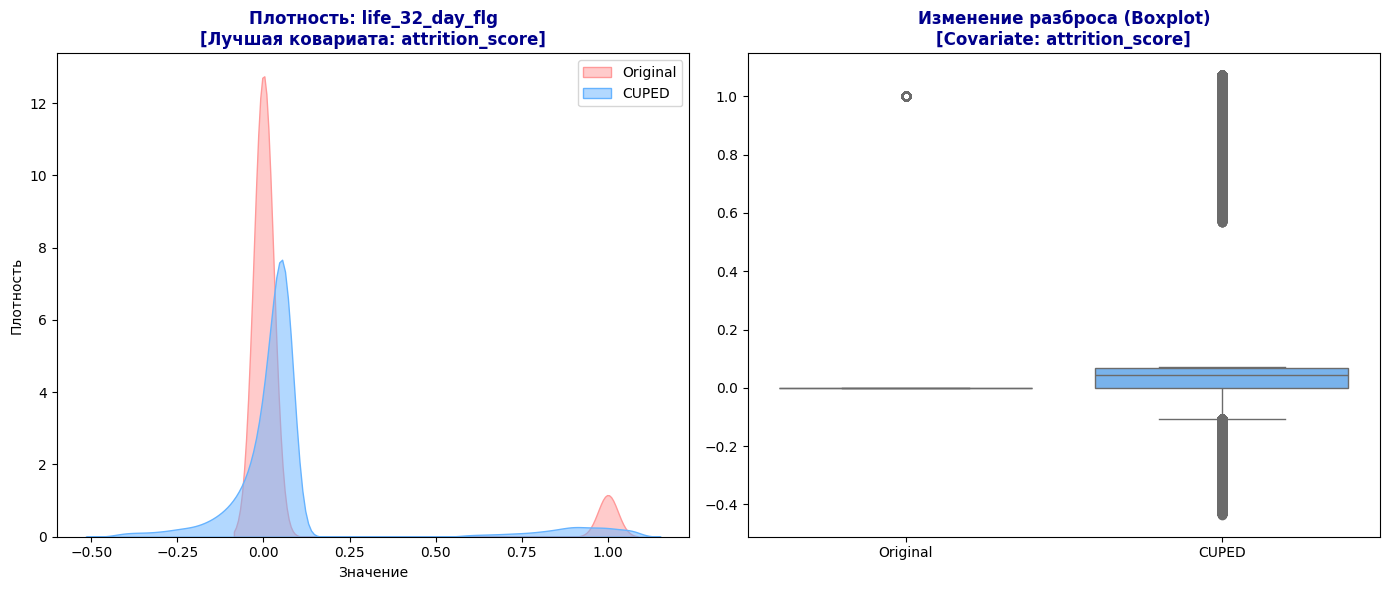

In [ ]:

for current_target in ALL_MY_TARGETS:
    print("\n" + "#"*70)
    print(f"### АНАЛИЗ МЕТРИКИ: {current_target}")
    print("#"*70)

    # 1. Формируем список "других" таргетов для удаления (защита от ликов)
    other_targets = [t for t in ALL_MY_TARGETS if t != current_target]

    # 2. Загрузка и очистка
    df_current = load_and_clean_data(DATA_PATH, target_col=current_target, other_targets=other_targets)

    # 3. Применение Single CUPED (возвращает датафрейм и название лучшей фичи)
    df_current, best_covariate = apply_single_cuped(df_current, target_col=current_target)

    # 4. Визуализация
    cuped_col = f"{current_target}_cuped"

    # Сделали графики чуть выше (figsize=(14,6)), чтобы влезли заголовки
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Левый график (Плотность)
    sns.kdeplot(df_current[current_target], label='Original', fill=True, ax=axes[0], color='#ff9999', alpha=0.5)
    sns.kdeplot(df_current[cuped_col], label='CUPED', fill=True, ax=axes[0], color='#66b3ff', alpha=0.5)

    # !!! ТУТ ВЫВОДИМ ЛУЧШУЮ КОВАРИАТУ В ЗАГОЛОВОК !!!
    axes[0].set_title(f'Плотность: {current_target}\n[Лучшая ковариата: {best_covariate}]',
                      fontsize=12, fontweight='bold', color='darkblue')
    axes[0].set_xlabel('Значение')
    axes[0].set_ylabel('Плотность')
    axes[0].legend()

    # Правый график (Boxplot)
    data_to_plot = pd.DataFrame({'Original': df_current[current_target], 'CUPED': df_current[cuped_col]})
    sns.boxplot(data=data_to_plot, ax=axes[1], palette=['#ff9999', '#66b3ff'])
    axes[1].set_title(f'Изменение разброса (Boxplot)\n[Covariate: {best_covariate}]',
                      fontsize=12, fontweight='bold', color='darkblue')

    plt.tight_layout()
    plt.show()

In [ ]:
df

# Обычный Мульти купед

## 2. Vanilla Multi-CUPED (Множественный CUPED на базе OLS)

Вместо одной ковариаты используется вся матрица признаков $\mathbf{X}$. Чтобы свести задачу к классической формуле CUPED, мы строим модель машинного обучения (в данном случае линейную регрессию), которая предсказывает таргет $\hat{Y}$. Это предсказание выступает в роли "супер-ковариаты".

**Шаг 1. Избежание переобучения (Out-of-Fold кросс-валидация):**
Если обучить модель и сделать предсказание на тех же данных, модель переобучится, и корреляция $\rho(Y, \hat{Y})$ будет завышена. Чтобы этого избежать, выборка разбивается на $K=5$ фолдов.
Пусть $D_k$ — валидационный фолд, а $D_{-k}$ — тренировочная часть (все остальные фолды).
Для каждого фолда $k$ обучается вектор весов $\mathbf{w}_k$:
$$ \mathbf{w}_k = (\mathbf{X}_{-k}^T \mathbf{X}_{-k})^{-1} \mathbf{X}_{-k}^T Y_{-k} $$

**Шаг 2. Получение OOF-предсказаний:**
Для каждого объекта $i \in D_k$ строится предсказание:
$$ \hat{Y}_{oof}^{(i)} = \mathbf{x}_i^T \mathbf{w}_k $$

**Шаг 3. CUPED трансформация:**
Теперь предсказание $\hat{Y}_{oof}$ используется как единственная ковариата:
$$ \theta = \frac{\text{Cov}(Y, \hat{Y}_{oof})}{\text{Var}(\hat{Y}_{oof})} $$
$$ Y_{cuped}^{(i)} = Y^{(i)} - \theta \left( \hat{Y}_{oof}^{(i)} - \overline{\hat{Y}_{oof}} \right) $$
*(Примечание: для идеальной линейной регрессии без регуляризации $\theta$ будет стремиться к 1).*


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from collections import Counter
import warnings

# ==========================================
# 1. ЗАГРУЗКА И ОЧИСТКА ДАННЫХ
# ==========================================
def load_and_clean_data(filepath, target_col, other_targets):
    print(f"[{target_col}] Загрузка и очистка данных...")
    df = pd.read_csv(filepath)
    df = df.replace(-1, 0).fillna(0)

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df = df[numeric_cols]

    # Исключение других таргетов (Target Leakage)
    drop_targets = [c for c in other_targets if c in df.columns]
    if drop_targets:
        df = df.drop(columns=drop_targets)
        print(f"Удалены другие таргеты: {drop_targets}")

    # Константные признаки
    const_cols = [c for c in df.columns if df[c].nunique() <= 1]
    if const_cols:
        df = df.drop(columns=const_cols)

    # Редкие бинарки (< 100 наблюдений)
    rare_cols = [c for c in df.columns if df[c].nunique() == 2 and df[c].value_counts().min() < 100]
    if rare_cols:
        df = df.drop(columns=rare_cols)

    print(f"Итоговый размер датасета: {df.shape}\n")
    return df

# ==========================================
# 2. VANILLA MULTI-CUPED (OUT-OF-FOLD)
# ==========================================
def apply_vanilla_multi_cuped(df, target_col, top_k=10, n_splits=5):
    print(f"Шаг 2. Запуск Vanilla OOF Multi-CUPED для метрики: {target_col}")

    cuped_col = f"{target_col}_cuped"
    df[cuped_col] = df[target_col].astype(float)

    excluded_features = {target_col, cuped_col}
    potential_covs = [c for c in df.columns if c not in excluded_features]

    y_real = df[target_col].values
    y_hat_oof = np.zeros(len(df))
    best_features_per_fold = []

    # 5-Fold Cross Validation для честного предсказания
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    print("Обучение OLS по фолдам...")
    for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
        df_train = df.iloc[train_idx]
        df_val = df.iloc[val_idx]
        y_train = y_real[train_idx]

        # Глушим ворнинги numpy (когда стандартное отклонение в фолде = 0)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            # Отбираем топ-K фичей только на Train
            correlations = df_train[potential_covs].corrwith(pd.Series(y_train, index=df_train.index)).abs().dropna()

        best_features = correlations.nlargest(top_k).index.tolist()
        best_features_per_fold.extend(best_features)

        # Обучаем линейную регрессию на Train, предсказываем Val
        model = LinearRegression()
        model.fit(df_train[best_features], y_train)
        y_hat_oof[val_idx] = model.predict(df_val[best_features])

        print(f"  Фолд {fold+1}/{n_splits} завершен.")

    # Вычисление ГЛОБАЛЬНОЙ Theta
    var_y_hat = np.var(y_hat_oof)
    if var_y_hat > 0:
        theta = np.cov(y_real, y_hat_oof)[0, 1] / var_y_hat
    else:
        theta = 0

    # ГЛОБАЛЬНАЯ ФОРМУЛА CUPED
    y_cuped = y_real - theta * (y_hat_oof - np.mean(y_hat_oof))
    df[cuped_col] = y_cuped

    # Статистика
    var_before = np.var(y_real)
    var_after = np.var(y_cuped)
    reduction = 1 - (var_after / var_before) if var_before > 0 else 0

    top_overall_features = [f[0] for f in Counter(best_features_per_fold).most_common(top_k)]

    print("\n" + "="*50)
    print(f"РЕЗУЛЬТАТЫ VANILLA MULTI-CUPED: {target_col}")
    print("="*50)
    print(f"Самые стабильные Топ-{top_k} ковариат: \n{top_overall_features}")
    print(f"Оптимальная Theta (\u03B8): {theta:.4f}")
    print(f"Общая дисперсия ДО:    {var_before:.2f}")
    print(f"Общая дисперсия ПОСЛЕ: {var_after:.2f}")
    print(f"ОБЩЕЕ СНИЖЕНИЕ VAR:    {reduction * 100:.2f}%")
    print("="*50)

    return df




######################################################################
### АНАЛИЗ МЕТРИКИ: orig_cost_sum
######################################################################
[orig_cost_sum] Загрузка и очистка данных...
Удалены другие таргеты: ['life_1_day_flg', 'life_32_day_flg']
Итоговый размер датасета: (83208, 327)

Шаг 2. Запуск Vanilla OOF Multi-CUPED для метрики: orig_cost_sum
Обучение OLS по фолдам...
  Фолд 1/5 завершен.
  Фолд 2/5 завершен.
  Фолд 3/5 завершен.
  Фолд 4/5 завершен.
  Фолд 5/5 завершен.

РЕЗУЛЬТАТЫ VANILLA MULTI-CUPED: orig_cost_sum
Самые стабильные Топ-10 ковариат: 
['attrition_score', 'nfu_flg', 'Premium_0', 'ag', 'Premium_1', 'Deneg_bolee_10tys_0', 'en', 'Deneg_bolee_10tys_1', 'Deneg_bolee_10tys_2', 'Premium_2']
Оптимальная Theta (θ): 0.9977
Общая дисперсия ДО:    131554.08
Общая дисперсия ПОСЛЕ: 122943.18
ОБЩЕЕ СНИЖЕНИЕ VAR:    6.55%


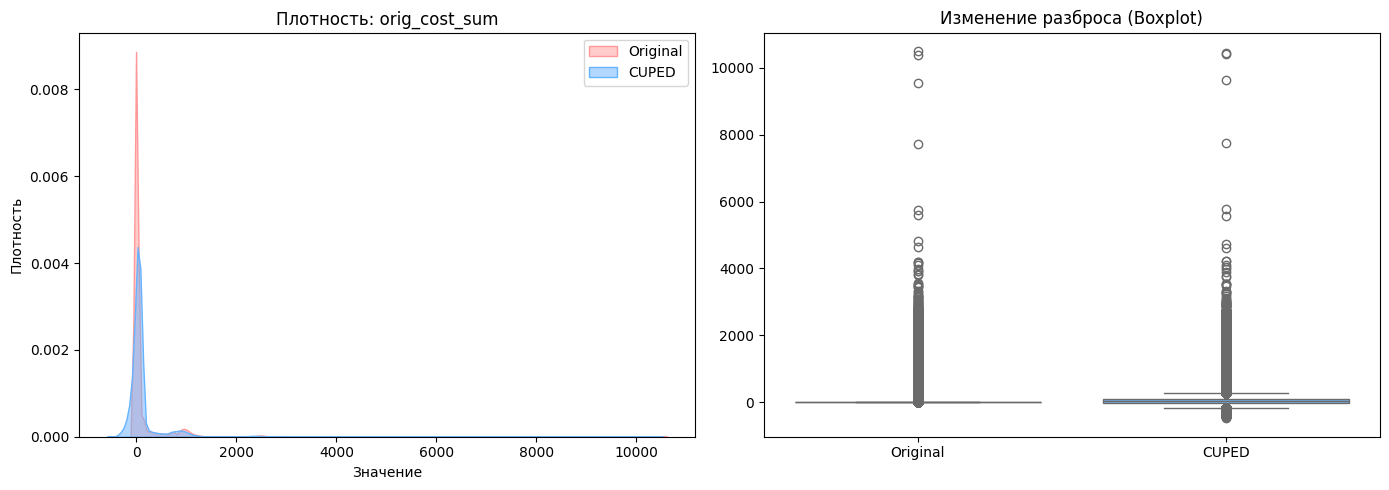


######################################################################
### АНАЛИЗ МЕТРИКИ: life_1_day_flg
######################################################################
[life_1_day_flg] Загрузка и очистка данных...
Удалены другие таргеты: ['orig_cost_sum', 'life_32_day_flg']
Итоговый размер датасета: (83208, 327)

Шаг 2. Запуск Vanilla OOF Multi-CUPED для метрики: life_1_day_flg
Обучение OLS по фолдам...
  Фолд 1/5 завершен.
  Фолд 2/5 завершен.
  Фолд 3/5 завершен.
  Фолд 4/5 завершен.
  Фолд 5/5 завершен.

РЕЗУЛЬТАТЫ VANILLA MULTI-CUPED: life_1_day_flg
Самые стабильные Топ-10 ковариат: 
['attrition_score', 'ag', 'nfu_flg', 'Deneg_bolee_10tys_0', 'Deneg_bolee_10tys_1', 'Deneg_bolee_10tys_2', 'app_xsell_total_dozv_flg', 'app_xsell_total_dudo_flg', 'auto', 'en']
Оптимальная Theta (θ): 0.9975
Общая дисперсия ДО:    0.16
Общая дисперсия ПОСЛЕ: 0.14
ОБЩЕЕ СНИЖЕНИЕ VAR:    14.72%


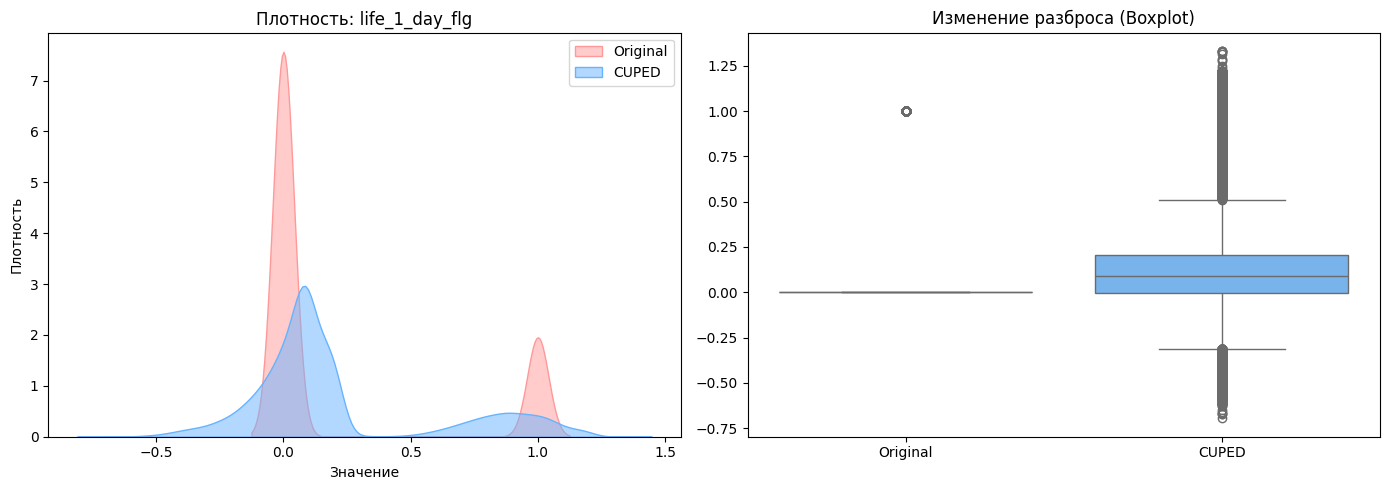


######################################################################
### АНАЛИЗ МЕТРИКИ: life_32_day_flg
######################################################################
[life_32_day_flg] Загрузка и очистка данных...
Удалены другие таргеты: ['orig_cost_sum', 'life_1_day_flg']
Итоговый размер датасета: (83208, 327)

Шаг 2. Запуск Vanilla OOF Multi-CUPED для метрики: life_32_day_flg
Обучение OLS по фолдам...
  Фолд 1/5 завершен.
  Фолд 2/5 завершен.
  Фолд 3/5 завершен.
  Фолд 4/5 завершен.
  Фолд 5/5 завершен.

РЕЗУЛЬТАТЫ VANILLA MULTI-CUPED: life_32_day_flg
Самые стабильные Топ-10 ковариат: 
['attrition_score', 'Deneg_bolee_10tys_0', 'Deneg_bolee_10tys_1', 'Deneg_bolee_10tys_2', 'ag', 'nfu_flg', 'Chislo_aktivnyh_produktov_0', 'Chislo_aktivnyh_produktov_1', 'Chislo_aktivnyh_produktov_2', 'en']
Оптимальная Theta (θ): 0.9986
Общая дисперсия ДО:    0.08
Общая дисперсия ПОСЛЕ: 0.07
ОБЩЕЕ СНИЖЕНИЕ VAR:    13.32%


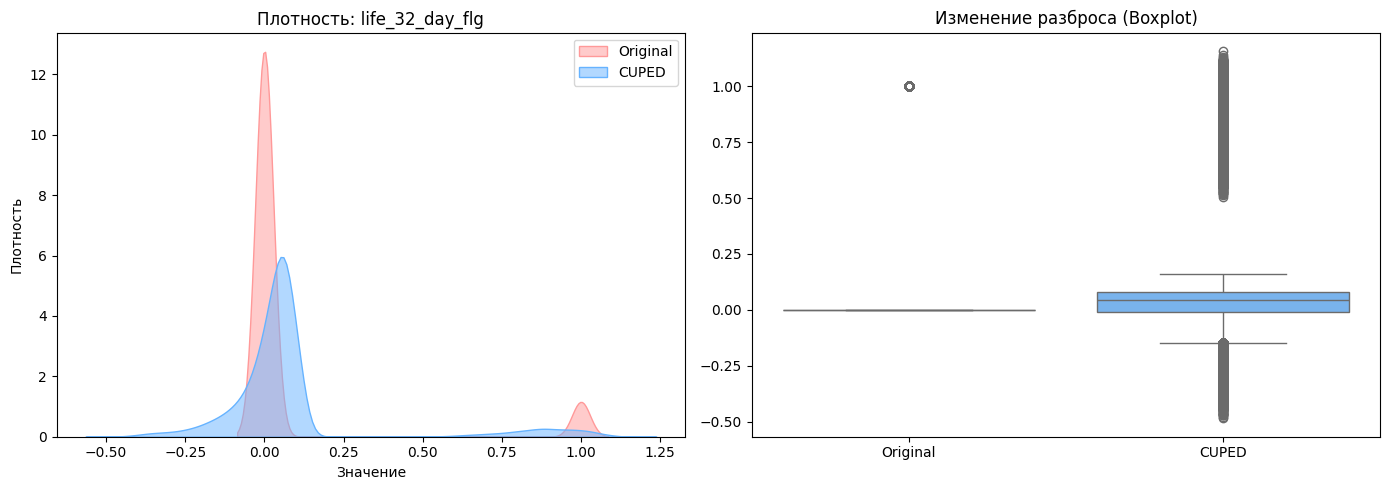

In [ ]:
# ==========================================
# ЗАПУСК PIPELINE ДЛЯ ВСЕХ МЕТРИК СРАЗУ
# ==========================================
DATA_PATH = '/content/drive/MyDrive/курсач/dataset_back.csv'
ALL_MY_TARGETS = ['orig_cost_sum', 'life_1_day_flg', 'life_32_day_flg']

for current_target in ALL_MY_TARGETS:
    print("\n" + "#"*70)
    print(f"### АНАЛИЗ МЕТРИКИ: {current_target}")
    print("#"*70)

    # 1. Формируем список "других" таргетов для удаления (чтобы не было утечки)
    other_targets = [t for t in ALL_MY_TARGETS if t != current_target]

    # 2. Загрузка и очистка
    df_current = load_and_clean_data(DATA_PATH, target_col=current_target, other_targets=other_targets)

    # 3. Применение Vanilla Multi-CUPED
    df_current = apply_vanilla_multi_cuped(df_current, target_col=current_target, top_k=10, n_splits=5)

    # 4. Визуализация
    cuped_col = f"{current_target}_cuped"
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.kdeplot(df_current[current_target], label='Original', fill=True, ax=axes[0], color='#ff9999', alpha=0.5)
    sns.kdeplot(df_current[cuped_col], label='CUPED', fill=True, ax=axes[0], color='#66b3ff', alpha=0.5)
    axes[0].set_title(f'Плотность: {current_target}', fontsize=12)
    axes[0].set_xlabel('Значение')
    axes[0].set_ylabel('Плотность')
    axes[0].legend()

    data_to_plot = pd.DataFrame({'Original': df_current[current_target], 'CUPED': df_current[cuped_col]})
    sns.boxplot(data=data_to_plot, ax=axes[1], palette=['#ff9999', '#66b3ff'])
    axes[1].set_title('Изменение разброса (Boxplot)', fontsize=12)

    plt.tight_layout()
    plt.show()

## Стратифицированный Multi CUPED


## 3. Стратифицированный Multi-CUPED

Пользователи могут иметь разное поведение. Глобальная линейная регрессия может не улавливать эти особенности. Идея в том, чтобы разбить пользователей на гомогенные страты (группы) и применить Multi-CUPED внутри каждой из них.

**Шаг 1. Дерево стратификации:**
Строится дерево решений (`DecisionTreeRegressor`) с ограничением `max_leaf_nodes=4`. Дерево делит пространство признаков $\mathbf{X}$ на непересекающиеся области (страты) $S_1, S_2, \dots, S_m$, минимизируя дисперсию таргета внутри листьев. Дерево обучается в режиме OOF, чтобы избежать утечки.

**Шаг 2. Локальный Ridge Multi-CUPED:**
Для каждой страты $j \in \{1 \dots m\}$ берется своя подвыборка пользователей. Так как размер страты может быть небольшим, обычная линейная регрессия (OLS) подвержена мультиколлинеарности и сильному переобучению. Поэтому используется $L_2$-регуляризация (Ridge):
$$ \mathbf{w}_j = \arg\min_{\mathbf{w}} \left( \sum_{i \in S_j} (Y^{(i)} - \mathbf{x}_i^T \mathbf{w})^2 + \lambda ||\mathbf{w}||_2^2 \right) $$

**Шаг 3. Локальный $\theta$ и CUPED:**
Для каждой страты $j$ рассчитывается свой оптимальный $\theta_j$ на основе OOF-предсказаний $\hat{Y}_{ridge}$ внутри этой страты:
$$ \theta_j = \frac{\text{Cov}(Y_{S_j}, \hat{Y}_{ridge, S_j})}{\text{Var}(\hat{Y}_{ridge, S_j})} $$
$$ Y_{cuped}^{(i)} = Y^{(i)} - \theta_j \left( \hat{Y}_{ridge}^{(i)} - \overline{\hat{Y}_{ridge, S_j}} \right), \quad \forall i \in S_j $$


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# ХЕЛПЕР: УМНАЯ КРОСС-ВАЛИДАЦИЯ (Правка 2)
# ==========================================
def get_cv_splits(df, target_col, n_splits=5):
    """
    Возвращает индексы для OOF, учитывая тип метрики (бинарная или непрерывная).
    Для непрерывных делает квантильную стратификацию.
    """
    y = df[target_col].values
    is_binary = len(np.unique(y)) == 2

    if is_binary:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        return list(skf.split(df, y))
    else:
        try:
            # Квантильная стратификация для непрерывных метрик
            bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
            if len(np.unique(bins)) <= 1:
                raise ValueError("Слишком много одинаковых значений, fallback to KFold")
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            return list(skf.split(df, bins))
        except:
            # Fallback, если qcut не смог разбить на корзины
            kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
            return list(kf.split(df))


# ==========================================
# 1. ОЧИСТКА ДАННЫХ
# ==========================================
def prepare_data_for_target(df_raw, target_col, other_targets):
    print(f"[{target_col}] Подготовка и очистка данных...")
    df = df_raw.copy()
    df = df.replace(-1, 0).fillna(0)

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df = df[numeric_cols]

    drop_targets = [c for c in other_targets if c in df.columns]
    if drop_targets:
        df = df.drop(columns=drop_targets)

    blacklist = ['fuck']
    drop_cols = [c for c in df.columns if c != target_col and any(w in c.lower() for w in blacklist)]
    if drop_cols:
        df = df.drop(columns=drop_cols)

    const_cols = [c for c in df.columns if df[c].nunique() <= 1]
    if const_cols:
        df = df.drop(columns=const_cols)

    rare_cols = [c for c in df.columns if df[c].nunique() == 2 and df[c].value_counts().min() < 100]
    if rare_cols:
        df = df.drop(columns=rare_cols)

    print(f"  Итоговый размер датасета под этот таргет: {df.shape}\n")
    return df

# ==========================================
# 2. ЧЕСТНАЯ OOF СТРАТИФИКАЦИЯ (Правка 1)
# ==========================================
def create_strata_tree_oof(df, target_col, n_strata=4, n_splits=5):
    print(f"[{target_col}] Шаг 1. Честная OOF стратификация (Outer CV)...")

    features = [c for c in df.columns if c != target_col]
    df['stratum'] = -1

    cv_splits = get_cv_splits(df, target_col, n_splits=n_splits)

    for train_idx, val_idx in cv_splits:
        X_train, y_train = df.iloc[train_idx][features], df.iloc[train_idx][target_col]
        X_val = df.iloc[val_idx][features]

        # Строим дерево на 4 фолдах, предсказываем листья (страты) для 5-го
        tree = DecisionTreeRegressor(max_leaf_nodes=n_strata, min_samples_leaf=1000, random_state=42)
        tree.fit(X_train, y_train)

        # Получаем номер листа для валидации
        df.loc[df.index[val_idx], 'stratum'] = tree.apply(X_val)

    print(f"  Готово! OOF Датасет поделен на {df['stratum'].nunique()} страты.")
    for s in sorted(df['stratum'].unique()):
        print(f"    Страта {s}: {sum(df['stratum'] == s)} клиентов")
    return df

# ==========================================
# 3. OOF MULTI-CUPED С RIDGE-ОТБОРОМ (Правки 3 и 4)
# ==========================================
def apply_oof_multi_cuped(df, target_col, top_k=10, n_splits=5):
    print(f"\n[{target_col}] Шаг 2. Запуск OOF Multi-CUPED...")

    cuped_col = f"{target_col}_cuped"
    df[cuped_col] = df[target_col].astype(float)

    excluded_features = {target_col, cuped_col, 'stratum'}
    potential_covs = [c for c in df.columns if c not in excluded_features]

    logs = []

    for stratum_id in sorted(df['stratum'].unique()):
        idx = df['stratum'] == stratum_id
        df_local = df[idx].reset_index(drop=True)
        y_local = df_local[target_col].values

        y_hat_oof = np.zeros(len(df_local))
        best_features_per_fold = []

        # Снова используем стратифицированный/квантильный сплит ВНУТРИ страты
        inner_cv = get_cv_splits(df_local, target_col, n_splits=n_splits)

        for train_idx, val_idx in inner_cv:
            df_train, df_val = df_local.iloc[train_idx], df_local.iloc[val_idx]
            y_train = y_local[train_idx]

            if np.var(y_train) == 0:
                y_hat_oof[val_idx] = np.mean(y_train)
                continue

            # Правка 3: Отбор фичей через Ridge (вместо корреляций)
            scaler_fs = StandardScaler()
            X_train_scaled = scaler_fs.fit_transform(df_train[potential_covs])

            ridge_fs = Ridge(alpha=10.0)
            ridge_fs.fit(X_train_scaled, y_train)

            importances = np.abs(ridge_fs.coef_)
            best_idx = np.argsort(importances)[-top_k:]
            best_features = [potential_covs[i] for i in best_idx]
            best_features_per_fold.extend(best_features)

            if not best_features:
                y_hat_oof[val_idx] = np.mean(y_train)
                continue

            # Правка 3: Замена LinearRegression на Ridge(alpha=10)
            scaler_mod = StandardScaler()
            X_tr_best = scaler_mod.fit_transform(df_train[best_features])
            X_val_best = scaler_mod.transform(df_val[best_features])

            model = Ridge(alpha=10.0)
            model.fit(X_tr_best, y_train)
            y_hat_oof[val_idx] = model.predict(X_val_best)

        var_y_hat = np.var(y_hat_oof)
        if var_y_hat > 0:
            theta = np.cov(y_local, y_hat_oof)[0, 1] / var_y_hat
        else:
            theta = 0

        # CUPED
        local_cuped = y_local - theta * (y_hat_oof - np.mean(y_hat_oof))
        df.loc[idx, cuped_col] = local_cuped

        # Правка 4: Sanity Check (корреляция должна быть около 0)
        corr_sanity = np.corrcoef(local_cuped, y_hat_oof)[0, 1] if var_y_hat > 0 else 0

        var_before = np.var(y_local)
        var_after = np.var(local_cuped)
        reduction = 1 - (var_after / var_before) if var_before > 0 else 0

        top_overall_features = [f[0] for f in Counter(best_features_per_fold).most_common(5)]

        logs.append({
            'Страта': stratum_id,
            'Размер': len(df_local),
            'Топ-фичи': top_overall_features,
            'Theta': theta,
            'Sanity_Corr': corr_sanity,
            'Var до': var_before,
            'Var после': var_after,
            'Снижение %': reduction * 100
        })

    for log in logs:
        print(f"➔ Страта {log['Страта']} (Размер: {log['Размер']}, Theta: {log['Theta']:.4f})")
        print(f"   Частые фичи: {log['Топ-фичи']}")
        print(f"   Sanity-Check Corr(Y_cuped, Y_hat): {log['Sanity_Corr']:.4f} (Должно быть ~0)")
        print(f"   Дисперсия: {log['Var до']:.4f} ➔ {log['Var после']:.4f} (Снижение: {log['Снижение %']:.2f}%)")

    global_var_before = df[target_col].var()
    global_var_after = df[cuped_col].var()
    global_reduction = 1 - (global_var_after / global_var_before) if global_var_before > 0 else 0

    print("\n" + "="*50)
    print(f"ИТОГ ПО МЕТРИКЕ: {target_col}")
    print("="*50)
    print(f"Общая дисперсия ДО:    {global_var_before:.4f}")
    print(f"Общая дисперсия ПОСЛЕ: {global_var_after:.4f}")
    print(f"ОБЩЕЕ СНИЖЕНИЕ:        {global_reduction * 100:.2f}%")
    print("="*50)

    return df

# ==========================================
# 4. ВИЗУАЛИЗАЦИЯ
# ==========================================
def plot_results(df, target_col):
    cuped_col = f"{target_col}_cuped"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.kdeplot(df[target_col], label='Сырые данные (Original)', fill=True, ax=axes[0], color='#ff9999', alpha=0.5)
    sns.kdeplot(df[cuped_col], label='После CUPED', fill=True, ax=axes[0], color='#66b3ff', alpha=0.5)
    axes[0].set_title(f'Плотность: {target_col}', fontsize=12)
    axes[0].set_xlabel(target_col)
    axes[0].set_ylabel('Плотность')
    axes[0].legend()

    data_to_plot = pd.DataFrame({'Original': df[target_col], 'CUPED': df[cuped_col]})
    sns.boxplot(data=data_to_plot, ax=axes[1], palette=['#ff9999', '#66b3ff'])
    axes[1].set_title('Изменение разброса (Boxplot)', fontsize=12)

    plt.tight_layout()
    plt.show()


In [ ]:
# ==========================================
# ГЛАВНЫЙ PIPELINE ЗАПУСКА
# ==========================================

DATA_PATH = '/content/drive/MyDrive/курсач/dataset_back.csv'
ALL_TARGETS = ['life_1_day_flg', 'life_32_day_flg', 'orig_cost_sum']

print("Загрузка исходного датасета один раз в память...")
# Раскомментируй эту строку для реального файла:
df_raw = pd.read_csv(DATA_PATH)

In [ ]:
df_raw


,nfu_flg,orig_cost_sum,life_1_day_flg,life_32_day_flg,channel_desc,flow_strategy_code,pdt,el,ms,cs,...,app_xsell_total_sale_flg,email_cnt_all,email_cnt_1,email_open_flg_sum,email_open_flg_sum_1,email_delivery_flg_sum,email_delivery_flg_sum_1,email_click_cnt_sum,email_click_cnt_sum_1,email_open_to_delivery_sum_ratio
0,1,0.00,0,0,МБ,NCD,0,-1,-1,0,...,0,19,11,0,0,7,3,0,0,0.000000
1,0,0.00,0,0,МБ,DAC,0,-1,-1,0,...,1,119,19,2,1,119,19,0,0,0.016807
2,1,0.00,0,0,МБ,DAC,0,0,1,0,...,0,6,1,5,1,6,1,0,0,0.833333
3,0,0.00,1,1,МБ,DAC,0,3,0,0,...,0,1,0,0,0,0,0,0,0,0.000000
4,0,1021.11,0,0,Web,FST,0,-1,-1,0,...,0,3,3,0,0,3,3,0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83203,0,0.00,0,0,МБ,DAC,-1,-1,-1,-1,...,0,101,16,1,0,53,7,0,0,0.018868
83204,0,841.76,0,0,Web,DAC,0,3,1,0,...,0,8,0,1,0,8,0,0,0,0.125000
83205,0,0.00,0,0,Другое,FST,-1,-1,-1,2,...,0,1,0,0,0,0,0,0,0,0.000000
83206,1,0.00,0,0,Web,DAC,0,-1,-1,0,...,0,32,3,2,0,32,3,0,0,0.062500


Загрузка исходного датасета один раз в память...


############################################################
### ЗАПУСК АНАЛИЗА ДЛЯ: LIFE_1_DAY_FLG
############################################################
[life_1_day_flg] Подготовка и очистка данных...
  Итоговый размер датасета под этот таргет: (83208, 327)

[life_1_day_flg] Шаг 1. Честная OOF стратификация (Outer CV)...
  Готово! OOF Датасет поделен на 4 страты.
    Страта 1: 63176 клиентов
    Страта 4: 2309 клиентов
    Страта 5: 13110 клиентов
    Страта 6: 4613 клиентов

[life_1_day_flg] Шаг 2. Запуск OOF Multi-CUPED...
➔ Страта 1 (Размер: 63176, Theta: 1.0012)
   Частые фичи: ['loyalty_score_0', 'attrition_score', 'ag', 'app_xsell_total_count', 'app_xsell_total_nedozv_flg']
   Sanity-Check Corr(Y_cuped, Y_hat): -0.0000 (Должно быть ~0)
   Дисперсия: 0.1160 ➔ 0.1057 (Снижение: 8.88%)
➔ Страта 4 (Размер: 2309, Theta: 0.3320)
   Частые фичи: ['session_duration_3_and', 'interchange_fee_01', 'Chislo_aktivnyh_produktov_0', 'ses

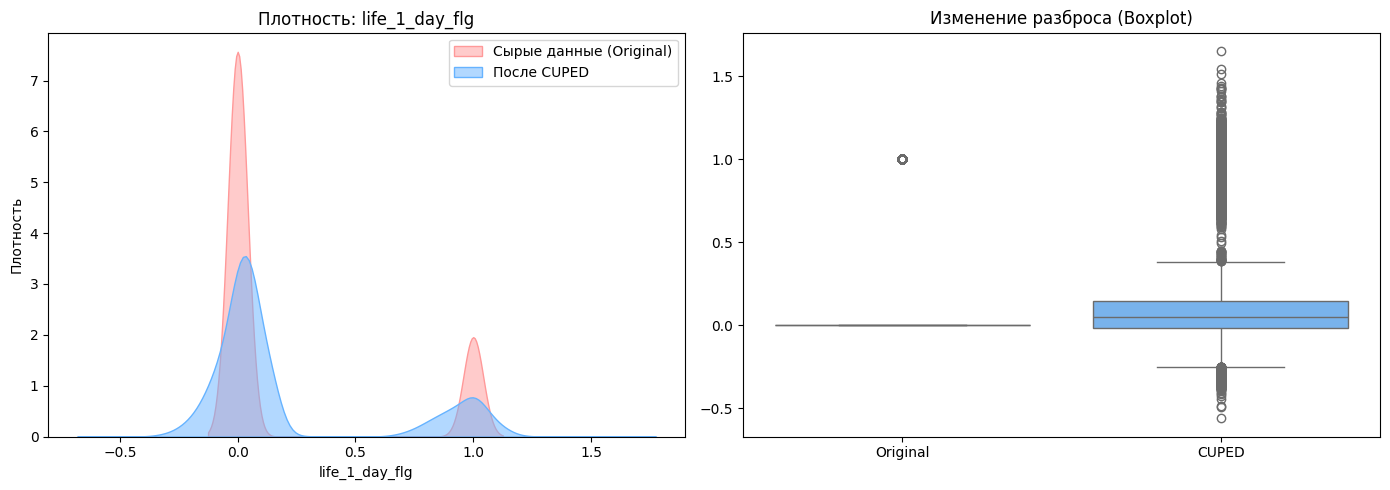



############################################################
### ЗАПУСК АНАЛИЗА ДЛЯ: LIFE_32_DAY_FLG
############################################################
[life_32_day_flg] Подготовка и очистка данных...
  Итоговый размер датасета под этот таргет: (83208, 327)

[life_32_day_flg] Шаг 1. Честная OOF стратификация (Outer CV)...
  Готово! OOF Датасет поделен на 4 страты.
    Страта 1: 68568 клиентов
    Страта 4: 2167 клиентов
    Страта 5: 10515 клиентов
    Страта 6: 1958 клиентов

[life_32_day_flg] Шаг 2. Запуск OOF Multi-CUPED...
➔ Страта 1 (Размер: 68568, Theta: 0.9882)
   Частые фичи: ['email_delivery_flg_sum_1', 'nfu_flg', 'attrition_score', 'email_cnt_1', 'app_xsell_total_dudo_flg']
   Sanity-Check Corr(Y_cuped, Y_hat): -0.0000 (Должно быть ~0)
   Дисперсия: 0.0398 ➔ 0.0382 (Снижение: 3.97%)
➔ Страта 4 (Размер: 2167, Theta: -0.1189)
   Частые фичи: ['Chislo_aktivnyh_produktov_1', 'Chislo_aktivnyh_produktov_0', 'session_duration_014_and', 'mvno_app_cnt', 'session_duration_3

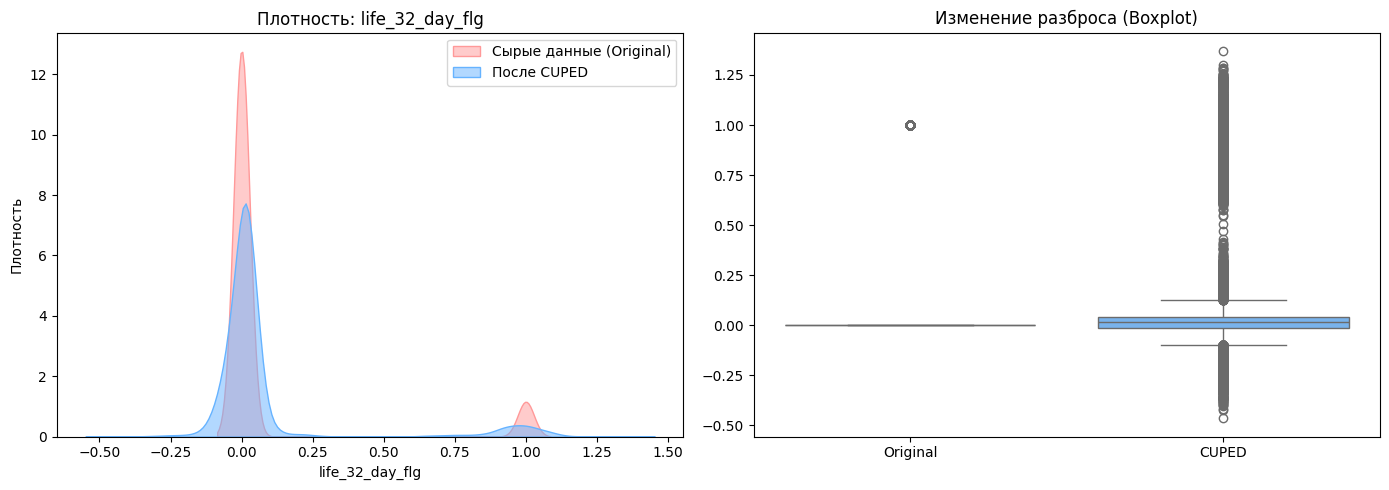



############################################################
### ЗАПУСК АНАЛИЗА ДЛЯ: ORIG_COST_SUM
############################################################
[orig_cost_sum] Подготовка и очистка данных...
  Итоговый размер датасета под этот таргет: (83208, 327)

[orig_cost_sum] Шаг 1. Честная OOF стратификация (Outer CV)...
  Готово! OOF Датасет поделен на 4 страты.
    Страта 2: 12142 клиентов
    Страта 3: 5620 клиентов
    Страта 5: 32652 клиентов
    Страта 6: 32794 клиентов

[orig_cost_sum] Шаг 2. Запуск OOF Multi-CUPED...
➔ Страта 2 (Размер: 12142, Theta: 0.2549)
   Частые фичи: ['app_xsell_total_dudo_flg', 'IIS_1', 'Avtoplatezh_1', 'Avtoplatezh_0', 'Investkopilka_0']
   Sanity-Check Corr(Y_cuped, Y_hat): -0.0000 (Должно быть ~0)
   Дисперсия: 373273.9511 ➔ 373179.3544 (Снижение: 0.03%)
➔ Страта 3 (Размер: 5620, Theta: 0.8860)
   Частые фичи: ['session_cnt_014_and', 'nfu_flg', 'ag', 'session_cnt_01_and', 'app_xsell_total_reject_flg']
   Sanity-Check Corr(Y_cuped, Y_hat): -0.0

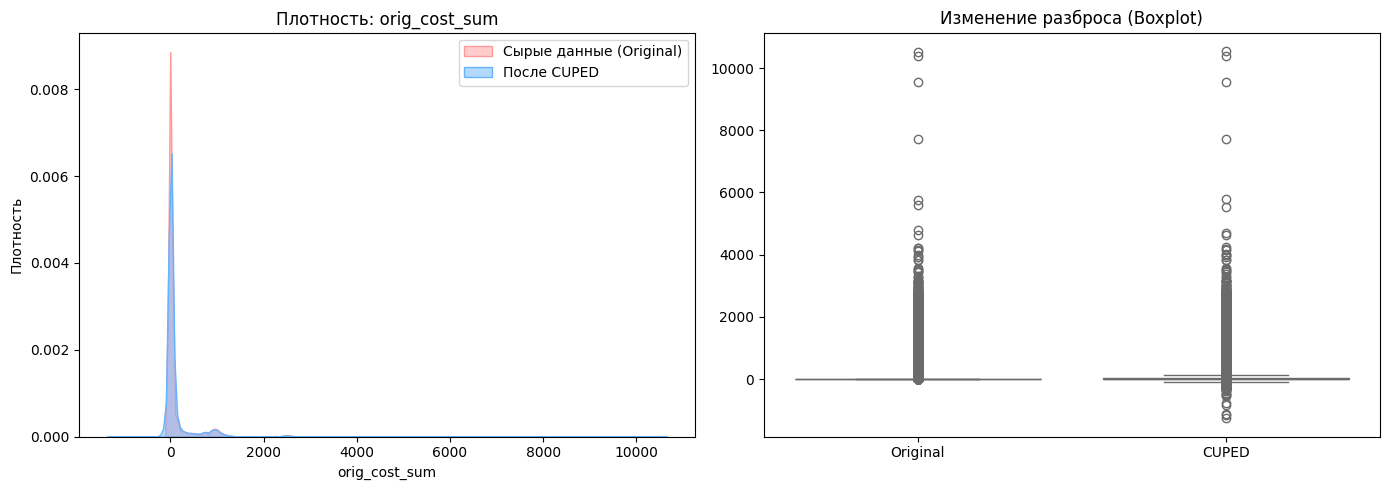

In [ ]:
# ==========================================
# ГЛАВНЫЙ PIPELINE ЗАПУСКА
# ==========================================

DATA_PATH = '/content/drive/MyDrive/курсач/dataset_back.csv'
ALL_TARGETS = ['life_1_day_flg', 'life_32_day_flg', 'orig_cost_sum']

print("Загрузка исходного датасета один раз в память...")
# Раскомментируй эту строку для реального файла:
df_raw = pd.read_csv(DATA_PATH)

processed_datasets = {}

for current_target in ALL_TARGETS:
    print(f"\n\n{'#'*60}")
    print(f"### ЗАПУСК АНАЛИЗА ДЛЯ: {current_target.upper()}")
    print(f"{'#'*60}")

    other_targets = [t for t in ALL_TARGETS if t != current_target]

    # 1. Очистка
    df_target = prepare_data_for_target(df_raw, target_col=current_target, other_targets=other_targets)

    # 2. OOF Стратификация (Без Leakage)
    df_target = create_strata_tree_oof(df_target, target_col=current_target, n_strata=4, n_splits=5)

    # 3. Применение ML-CUPED (с Ridge и честной кросс-валидацией)
    df_target = apply_oof_multi_cuped(df_target, target_col=current_target, top_k=10, n_splits=5)

    # 4. Визуализация
    plot_results(df_target, current_target)

    # Сохранение датасета
    processed_datasets[current_target] = df_target

# Интепретация дерева стратификации. Углубленное стратифицирование


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# ХЕЛПЕР: УМНАЯ КРОСС-ВАЛИДАЦИЯ
# ==========================================
def get_cv_splits(df, target_col, n_splits=5):
    y = df[target_col].values
    is_binary = len(np.unique(y)) == 2

    if is_binary:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        return list(skf.split(df, y))
    else:
        try:
            bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
            if len(np.unique(bins)) <= 1:
                raise ValueError("Слишком мало уникальных бинов")
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            return list(skf.split(df, bins))
        except:
            kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
            return list(kf.split(df))


# ==========================================
# 1. ОЧИСТКА ДАННЫХ
# ==========================================
def prepare_data_for_target(df_raw, target_col, other_targets):
    print(f"[{target_col}] Подготовка и очистка данных...")
    df = df_raw.copy()
    df = df.replace(-1, 0).fillna(0)

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df = df[numeric_cols]

    drop_targets = [c for c in other_targets if c in df.columns]
    if drop_targets:
        df = df.drop(columns=drop_targets)

    blacklist = ['fuck']
    drop_cols = [c for c in df.columns if c != target_col and any(w in c.lower() for w in blacklist)]
    if drop_cols:
        df = df.drop(columns=drop_cols)

    const_cols = [c for c in df.columns if df[c].nunique() <= 1]
    if const_cols:
        df = df.drop(columns=const_cols)

    rare_cols = [c for c in df.columns if df[c].nunique() == 2 and df[c].value_counts().min() < 100]
    if rare_cols:
        df = df.drop(columns=rare_cols)

    print(f"  Итоговый размер датасета под этот таргет: {df.shape}\n")
    return df

# ==========================================
# 2. ВИЗУАЛИЗАЦИЯ ДЕРЕВА СТРАТ (ДЛЯ ПРЕЗЕНТАЦИИ)
# ==========================================
def visualize_stratification_tree(df, target_col):
    print(f"\n{'='*50}")
    print(f"ВИЗУАЛИЗАЦИЯ СТРАТ ДЛЯ: {target_col}")
    print(f"{'='*50}")

    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Обучаем глобальное дерево с теми же параметрами, что и в OOF
    # Даем глубину 4 и запрещаем листья меньше 2000


    tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=2000, random_state=42)
    tree.fit(X, y)

    print("\nПравила разбиения (Как алгоритм думал):")
    print(export_text(tree, feature_names=list(X.columns)))

    plt.figure(figsize=(20, 10))
    plot_tree(
        tree,
        feature_names=X.columns,
        filled=True,
        rounded=True,
        fontsize=10,
        proportion=True,
        precision=3
    )
    plt.title(f'Умное разбиение на страты (Target: {target_col})\nmax_depth=4, min_samples_leaf=2000', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. ЧЕСТНАЯ OOF СТРАТИФИКАЦИЯ (ОБНОВЛЕННАЯ)
# ==========================================
def create_strata_tree_oof(df, target_col, n_splits=5):
    print(f"\n[{target_col}] Шаг 1. Честная OOF стратификация (Умное разбиение)...")

    features = [c for c in df.columns if c != target_col]
    df['stratum'] = -1

    cv_splits = get_cv_splits(df, target_col, n_splits=n_splits)

    for train_idx, val_idx in cv_splits:
        X_train, y_train = df.iloc[train_idx][features], df.iloc[train_idx][target_col]
        X_val = df.iloc[val_idx][features]

        # ИЗМЕНЕНИЯ: Глубина 4 (позволяет сделать до 16 страт), минимум 2000 человек на страту
        tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=2000, random_state=42)
        tree.fit(X_train, y_train)

        df.loc[df.index[val_idx], 'stratum'] = tree.apply(X_val)

    print(f"  Готово! Датасет поделен на {df['stratum'].nunique()} страты (вместо 4 старых).")
    for s in sorted(df['stratum'].unique()):
        print(f"    Страта {s}: {sum(df['stratum'] == s)} клиентов")
    return df

# ==========================================
# 4. OOF MULTI-CUPED С RIDGE-ОТБОРОМ
# ==========================================
def apply_oof_multi_cuped(df, target_col, top_k=10, n_splits=5):
    print(f"\n[{target_col}] Шаг 2. Запуск OOF Multi-CUPED...")

    cuped_col = f"{target_col}_cuped"
    df[cuped_col] = df[target_col].astype(float)

    excluded_features = {target_col, cuped_col, 'stratum'}
    potential_covs = [c for c in df.columns if c not in excluded_features]

    logs = []

    for stratum_id in sorted(df['stratum'].unique()):
        idx = df['stratum'] == stratum_id
        df_local = df[idx].reset_index(drop=True)
        y_local = df_local[target_col].values

        y_hat_oof = np.zeros(len(df_local))
        best_features_per_fold = []

        inner_cv = get_cv_splits(df_local, target_col, n_splits=n_splits)

        for train_idx, val_idx in inner_cv:
            df_train, df_val = df_local.iloc[train_idx], df_local.iloc[val_idx]
            y_train = y_local[train_idx]

            if np.var(y_train) == 0:
                y_hat_oof[val_idx] = np.mean(y_train)
                continue

            # Отбор 10 лучших фичей
            scaler_fs = StandardScaler()
            X_train_scaled = scaler_fs.fit_transform(df_train[potential_covs])

            ridge_fs = Ridge(alpha=10.0)
            ridge_fs.fit(X_train_scaled, y_train)

            importances = np.abs(ridge_fs.coef_)
            best_idx = np.argsort(importances)[-top_k:]
            best_features = [potential_covs[i] for i in best_idx]
            best_features_per_fold.extend(best_features)

            # Обучение только на 10 лучших фичах
            scaler_mod = StandardScaler()
            X_tr_best = scaler_mod.fit_transform(df_train[best_features])
            X_val_best = scaler_mod.transform(df_val[best_features])

            model = Ridge(alpha=10.0)
            model.fit(X_tr_best, y_train)
            y_hat_oof[val_idx] = model.predict(X_val_best)

        var_y_hat = np.var(y_hat_oof)
        theta = np.cov(y_local, y_hat_oof)[0, 1] / var_y_hat if var_y_hat > 0 else 0

        local_cuped = y_local - theta * (y_hat_oof - np.mean(y_hat_oof))
        df.loc[idx, cuped_col] = local_cuped

        var_before = np.var(y_local)
        var_after = np.var(local_cuped)
        reduction = 1 - (var_after / var_before) if var_before > 0 else 0

        logs.append({
            'Страта': stratum_id,
            'Размер': len(df_local),
            'Var до': var_before,
            'Var после': var_after,
            'Снижение %': reduction * 100
        })

    # Выводим логи компактно
    for log in logs:
        print(f"➔ Страта {log['Страта']:<4} | Размер: {log['Размер']:<6} | Снижение дисперсии: {log['Снижение %']:>5.2f}%")

    global_var_before = df[target_col].var()
    global_var_after = df[cuped_col].var()
    global_reduction = 1 - (global_var_after / global_var_before) if global_var_before > 0 else 0

    print("\n" + "="*50)
    print(f"ИТОГ ПО МЕТРИКЕ: {target_col}")
    print(f"Общая дисперсия ДО:    {global_var_before:.4f}")
    print(f"Общая дисперсия ПОСЛЕ: {global_var_after:.4f}")
    print(f"ОБЩЕЕ СНИЖЕНИЕ:        {global_reduction * 100:.2f}%")
    print("="*50)

    return df

# ==========================================
# 5. ВИЗУАЛИЗАЦИЯ ИЗМЕНЕНИЯ ПЛОТНОСТИ
# ==========================================
def plot_results(df, target_col):
    cuped_col = f"{target_col}_cuped"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.kdeplot(df[target_col], label='Original', fill=True, ax=axes[0], color='#ff9999', alpha=0.5)
    sns.kdeplot(df[cuped_col], label='CUPED', fill=True, ax=axes[0], color='#66b3ff', alpha=0.5)
    axes[0].set_title(f'Плотность: {target_col}', fontsize=12)
    axes[0].legend()

    data_to_plot = pd.DataFrame({'Original': df[target_col], 'CUPED': df[cuped_col]})
    sns.boxplot(data=data_to_plot, ax=axes[1], palette=['#ff9999', '#66b3ff'])
    axes[1].set_title('Изменение разброса (Boxplot)', fontsize=12)

    plt.tight_layout()
    plt.show()



Загрузка исходного датасета один раз в память...


############################################################
### ЗАПУСК АНАЛИЗА ДЛЯ: LIFE_1_DAY_FLG
############################################################
[life_1_day_flg] Подготовка и очистка данных...
  Итоговый размер датасета под этот таргет: (83208, 327)


ВИЗУАЛИЗАЦИЯ СТРАТ ДЛЯ: life_1_day_flg

Правила разбиения (Как алгоритм думал):
|--- attrition_score <= 0.19
|   |--- ag <= 20.50
|   |   |--- ag <= 16.00
|   |   |   |--- attrition_score <= 0.00
|   |   |   |   |--- value: [0.06]
|   |   |   |--- attrition_score >  0.00
|   |   |   |   |--- value: [0.00]
|   |   |--- ag >  16.00
|   |   |   |--- nfu_flg <= 0.50
|   |   |   |   |--- value: [0.17]
|   |   |   |--- nfu_flg >  0.50
|   |   |   |   |--- value: [0.06]
|   |--- ag >  20.50
|   |   |--- nfu_flg <= 0.50
|   |   |   |--- debit_card_app_cnt <= 1.50
|   |   |   |   |--- value: [0.35]
|   |   |   |--- debit_card_app_cnt >  1.50
|   |   |   |   |--- value: [0.18]
|   |

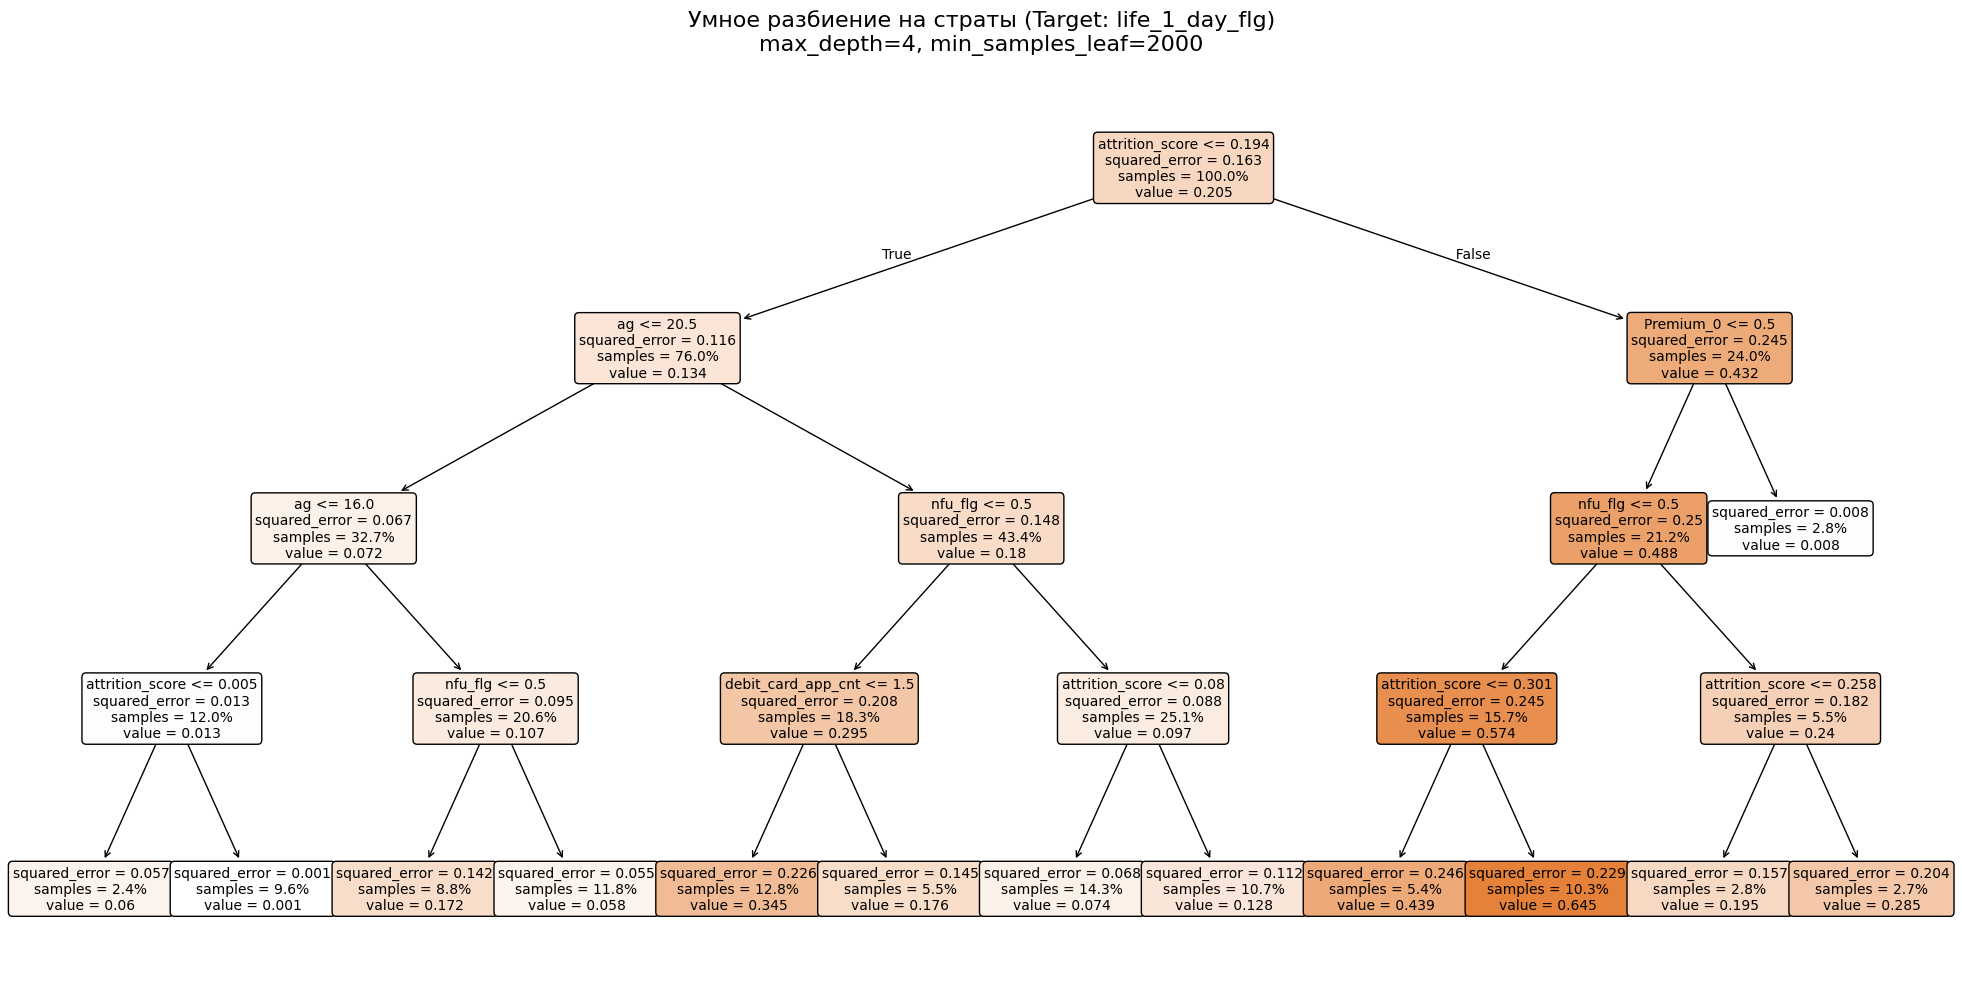


[life_1_day_flg] Шаг 1. Честная OOF стратификация (Умное разбиение)...
  Готово! Датасет поделен на 19 страты (вместо 4 старых).
    Страта 4: 2527 клиентов
    Страта 5: 7496 клиентов
    Страта 7: 7335 клиентов
    Страта 8: 9812 клиентов
    Страта 11: 10658 клиентов
    Страта 12: 4531 клиентов
    Страта 14: 13310 клиентов
    Страта 15: 7507 клиентов
    Страта 18: 2015 клиентов
    Страта 19: 1767 клиентов
    Страта 20: 3544 клиентов
    Страта 21: 1014 клиентов
    Страта 22: 2072 клиентов
    Страта 23: 1993 клиентов
    Страта 24: 2173 клиентов
    Страта 25: 1703 клиентов
    Страта 26: 2670 клиентов
    Страта 27: 519 клиентов
    Страта 28: 562 клиентов

[life_1_day_flg] Шаг 2. Запуск OOF Multi-CUPED...
➔ Страта 4    | Размер: 2527   | Снижение дисперсии: 12.94%
➔ Страта 5    | Размер: 7496   | Снижение дисперсии:  2.09%
➔ Страта 7    | Размер: 7335   | Снижение дисперсии:  1.41%
➔ Страта 8    | Размер: 9812   | Снижение дисперсии:  0.31%
➔ Страта 11   | Размер: 10658  |

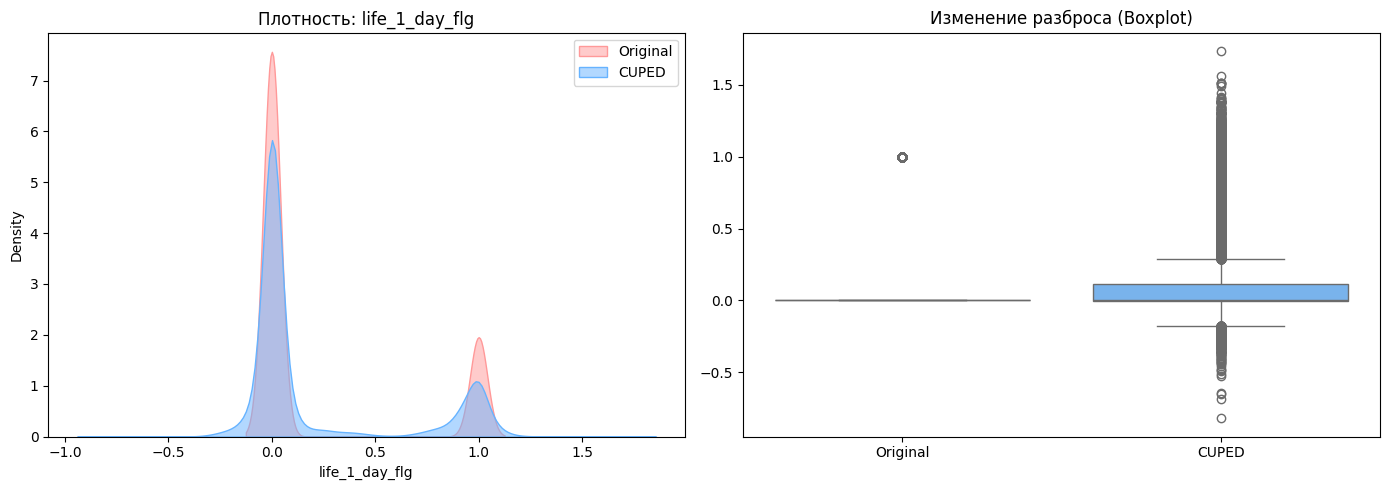



############################################################
### ЗАПУСК АНАЛИЗА ДЛЯ: LIFE_32_DAY_FLG
############################################################
[life_32_day_flg] Подготовка и очистка данных...
  Итоговый размер датасета под этот таргет: (83208, 327)


ВИЗУАЛИЗАЦИЯ СТРАТ ДЛЯ: life_32_day_flg

Правила разбиения (Как алгоритм думал):
|--- attrition_score <= 0.24
|   |--- attrition_score <= 0.12
|   |   |--- Est'_DK_1 <= 0.50
|   |   |   |--- ag <= 28.00
|   |   |   |   |--- value: [0.03]
|   |   |   |--- ag >  28.00
|   |   |   |   |--- value: [0.09]
|   |   |--- Est'_DK_1 >  0.50
|   |   |   |--- attrition_score <= 0.07
|   |   |   |   |--- value: [0.01]
|   |   |   |--- attrition_score >  0.07
|   |   |   |   |--- value: [0.04]
|   |--- attrition_score >  0.12
|   |   |--- nfu_flg <= 0.50
|   |   |   |--- ag <= 28.00
|   |   |   |   |--- value: [0.10]
|   |   |   |--- ag >  28.00
|   |   |   |   |--- value: [0.16]
|   |   |--- nfu_flg >  0.50
|   |   |   |--- attriti

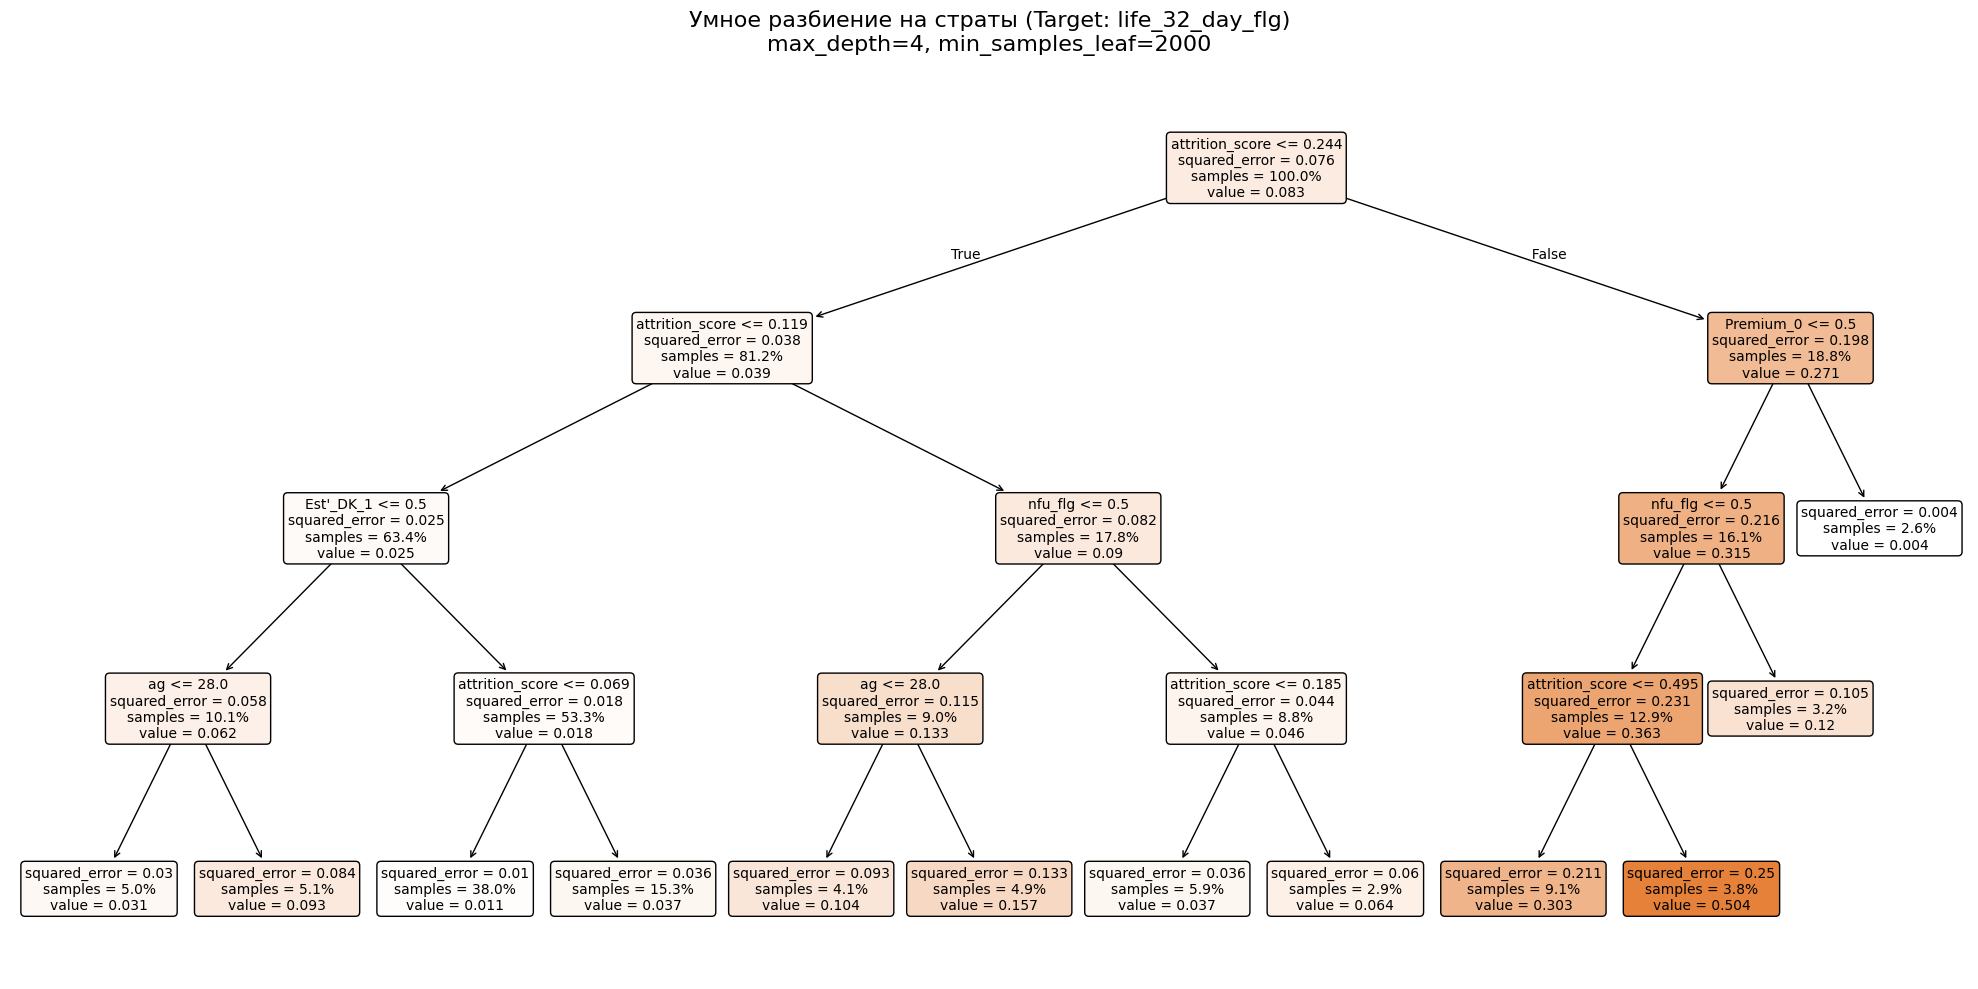


[life_32_day_flg] Шаг 1. Честная OOF стратификация (Умное разбиение)...
  Готово! Датасет поделен на 18 страты (вместо 4 старых).
    Страта 4: 9064 клиентов
    Страта 5: 5405 клиентов
    Страта 7: 26728 клиентов
    Страта 8: 13576 клиентов
    Страта 11: 3533 клиентов
    Страта 12: 3615 клиентов
    Страта 13: 966 клиентов
    Страта 14: 3206 клиентов
    Страта 15: 2475 клиентов
    Страта 16: 778 клиентов
    Страта 17: 470 клиентов
    Страта 18: 3245 клиентов
    Страта 19: 3236 клиентов
    Страта 20: 484 клиентов
    Страта 21: 742 клиентов
    Страта 22: 2407 клиентов
    Страта 23: 1658 клиентов
    Страта 24: 1620 клиентов

[life_32_day_flg] Шаг 2. Запуск OOF Multi-CUPED...
➔ Страта 4    | Размер: 9064   | Снижение дисперсии:  0.31%
➔ Страта 5    | Размер: 5405   | Снижение дисперсии:  1.86%
➔ Страта 7    | Размер: 26728  | Снижение дисперсии:  1.55%
➔ Страта 8    | Размер: 13576  | Снижение дисперсии:  0.72%
➔ Страта 11   | Размер: 3533   | Снижение дисперсии:  0.83%
➔ 

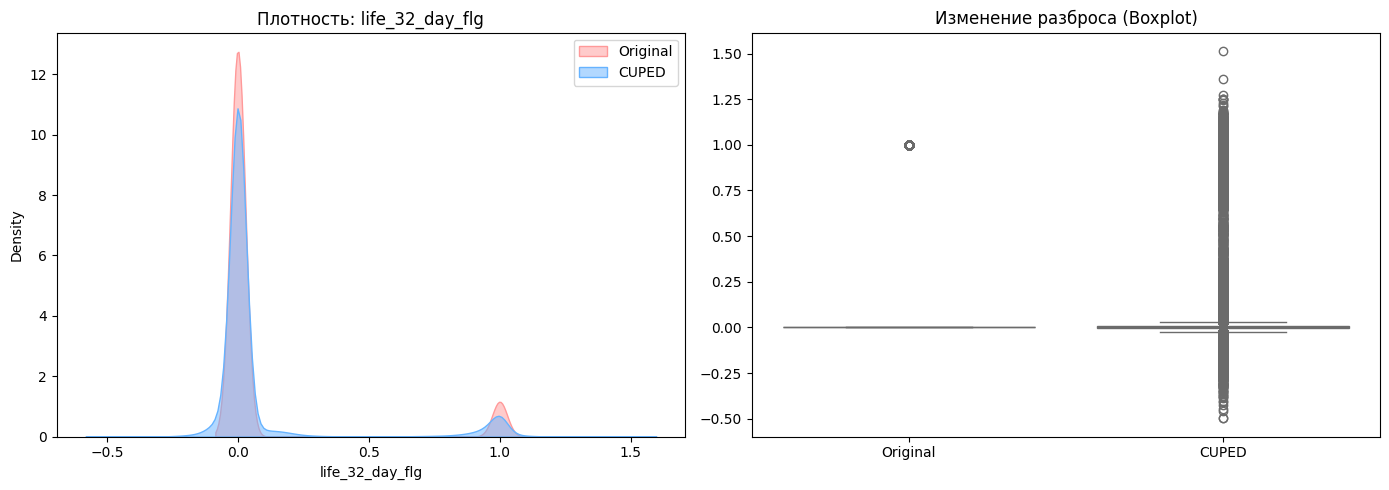



############################################################
### ЗАПУСК АНАЛИЗА ДЛЯ: ORIG_COST_SUM
############################################################
[orig_cost_sum] Подготовка и очистка данных...
  Итоговый размер датасета под этот таргет: (83208, 327)


ВИЗУАЛИЗАЦИЯ СТРАТ ДЛЯ: orig_cost_sum

Правила разбиения (Как алгоритм думал):
|--- attrition_score <= 0.30
|   |--- loyalty_score_0 <= 0.33
|   |   |--- debit_card_app_cnt <= 0.50
|   |   |   |--- value: [305.52]
|   |   |--- debit_card_app_cnt >  0.50
|   |   |   |--- value: [145.56]
|   |--- loyalty_score_0 >  0.33
|   |   |--- nfu_flg <= 0.50
|   |   |   |--- ag <= 16.00
|   |   |   |   |--- value: [4.68]
|   |   |   |--- ag >  16.00
|   |   |   |   |--- value: [134.03]
|   |   |--- nfu_flg >  0.50
|   |   |   |--- attrition_score <= 0.16
|   |   |   |   |--- value: [32.90]
|   |   |   |--- attrition_score >  0.16
|   |   |   |   |--- value: [67.05]
|--- attrition_score >  0.30
|   |--- session_duration_014_and <= 151.

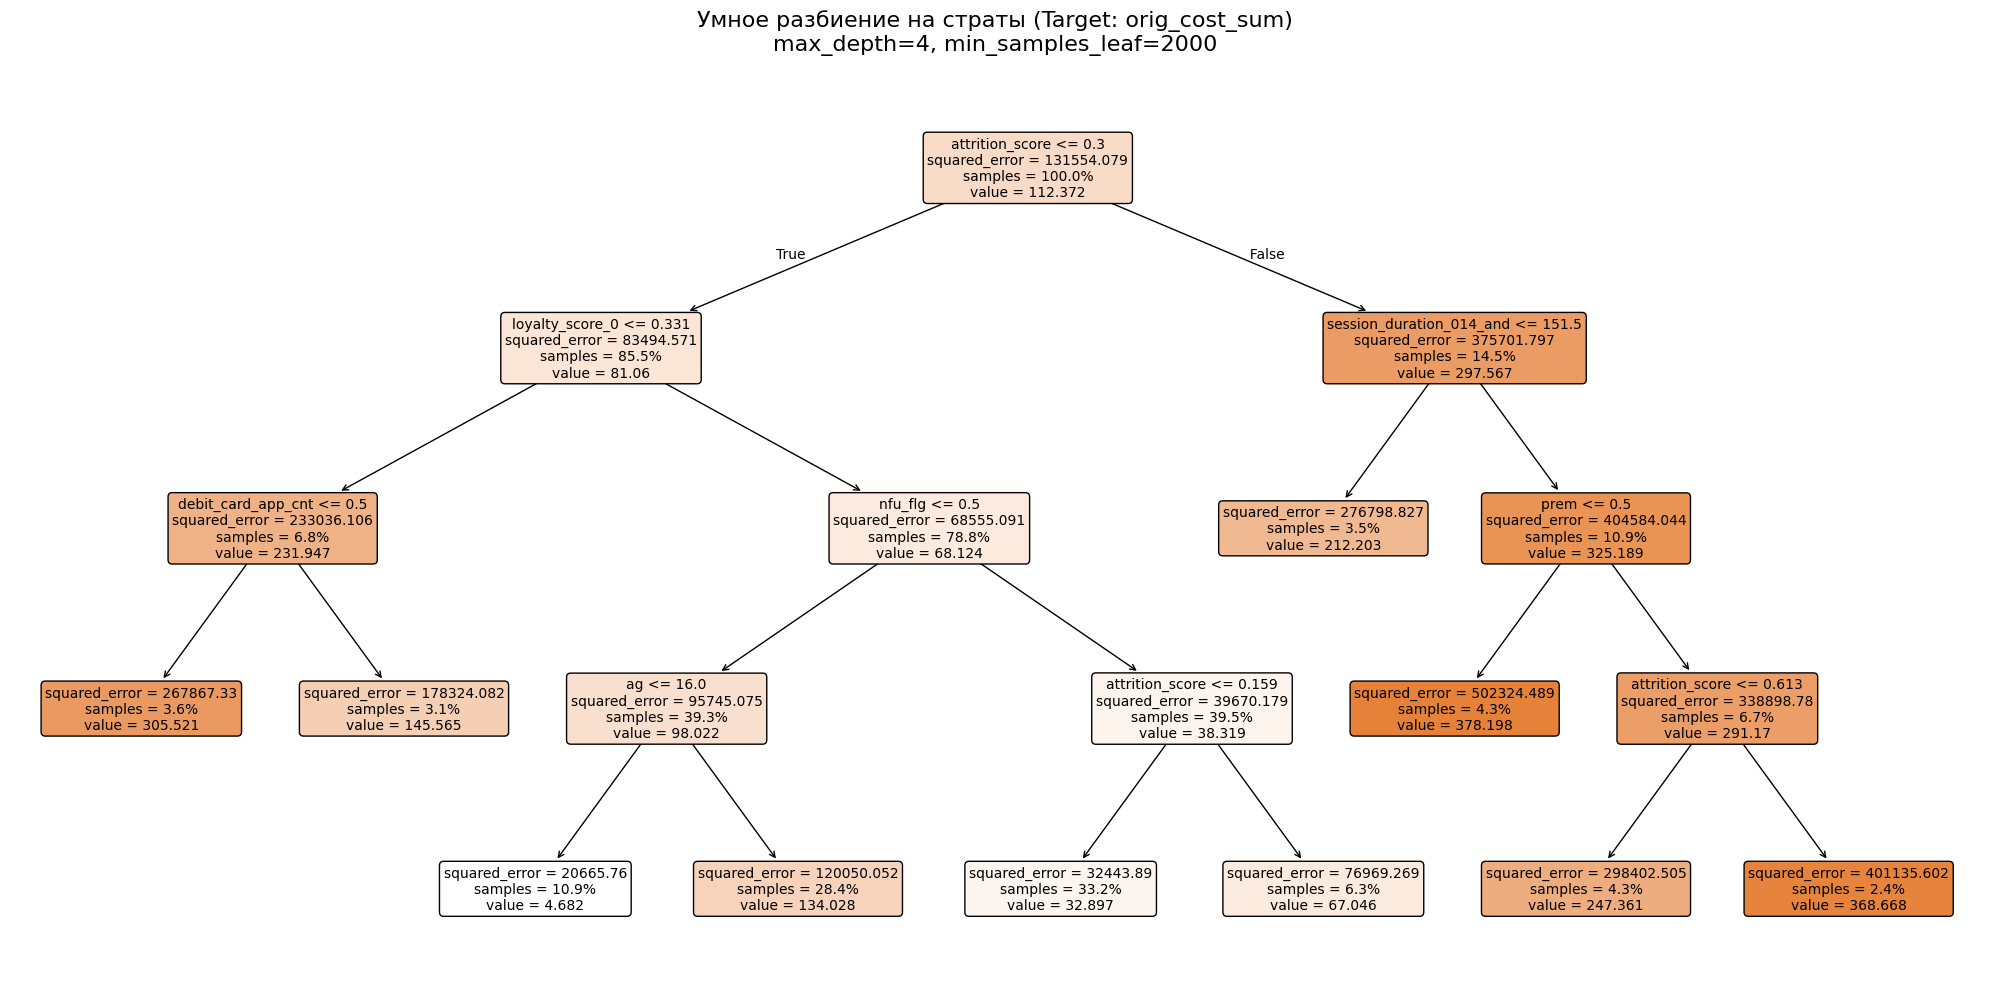


[orig_cost_sum] Шаг 1. Честная OOF стратификация (Умное разбиение)...
  Готово! Датасет поделен на 10 страты (вместо 4 старых).
    Страта 3: 3035 клиентов
    Страта 4: 2585 клиентов
    Страта 7: 9110 клиентов
    Страта 8: 23542 клиентов
    Страта 10: 25922 клиентов
    Страта 11: 6872 клиентов
    Страта 13: 2978 клиентов
    Страта 15: 3589 клиентов
    Страта 17: 2832 клиентов
    Страта 18: 2743 клиентов

[orig_cost_sum] Шаг 2. Запуск OOF Multi-CUPED...
➔ Страта 3    | Размер: 3035   | Снижение дисперсии:  7.61%
➔ Страта 4    | Размер: 2585   | Снижение дисперсии:  0.77%
➔ Страта 7    | Размер: 9110   | Снижение дисперсии:  0.00%
➔ Страта 8    | Размер: 23542  | Снижение дисперсии:  0.36%
➔ Страта 10   | Размер: 25922  | Снижение дисперсии:  0.01%
➔ Страта 11   | Размер: 6872   | Снижение дисперсии:  0.01%
➔ Страта 13   | Размер: 2978   | Снижение дисперсии:  0.68%
➔ Страта 15   | Размер: 3589   | Снижение дисперсии:  0.11%
➔ Страта 17   | Размер: 2832   | Снижение дисперсии: 

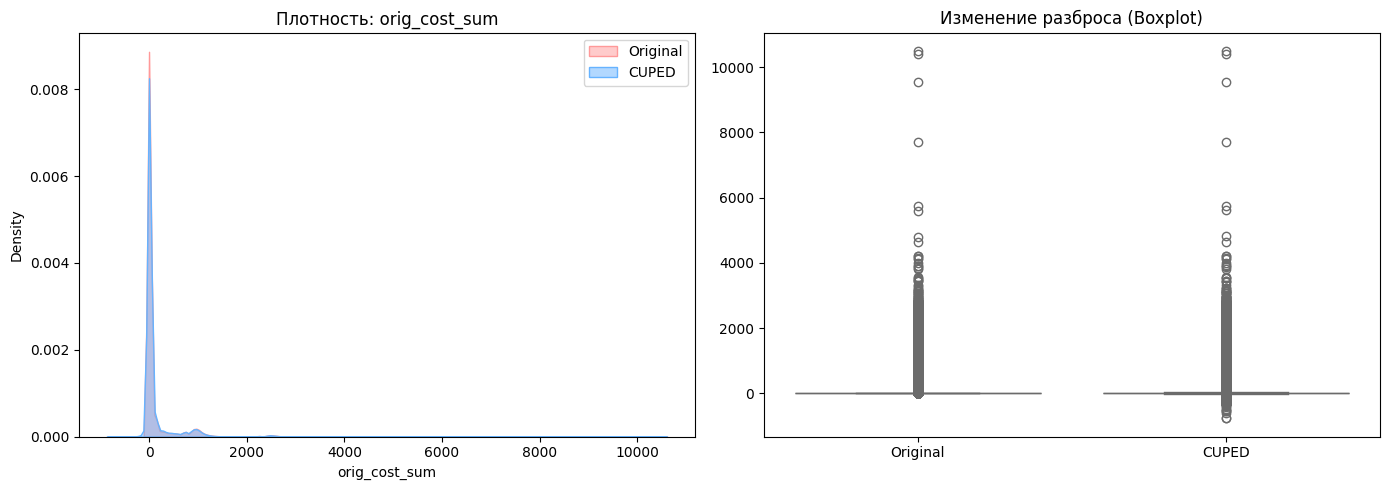

In [ ]:
# ==========================================
# ГЛАВНЫЙ PIPELINE ЗАПУСКА
# ==========================================

DATA_PATH = '/content/drive/MyDrive/курсач/dataset_back.csv'
ALL_TARGETS = ['life_1_day_flg', 'life_32_day_flg', 'orig_cost_sum']

print("Загрузка исходного датасета один раз в память...")
# В боевом запуске раскомментировать:
df_raw = pd.read_csv(DATA_PATH)

processed_datasets = {}

for current_target in ALL_TARGETS:
    print(f"\n\n{'#'*60}")
    print(f"### ЗАПУСК АНАЛИЗА ДЛЯ: {current_target.upper()}")
    print(f"{'#'*60}")

    other_targets = [t for t in ALL_TARGETS if t != current_target]

    # 1. Очистка
    df_target = prepare_data_for_target(df_raw, target_col=current_target, other_targets=other_targets)

    # для всех таргетов визуализация
    visualize_stratification_tree(df_target, current_target)

    # 3. Умная OOF Стратификация
    df_target = create_strata_tree_oof(df_target, target_col=current_target, n_splits=5)

    # 4. Применение OOF Multi-CUPED
    df_target = apply_oof_multi_cuped(df_target, target_col=current_target, top_k=10, n_splits=5)

    # 5. Отрисовка результатов (KDE + Boxplot)
    plot_results(df_target, current_target)

    processed_datasets[current_target] = df_target

In [ ]:
=========# =======+===================

# ML-cuped . Одна ковариата, на одной фичи, которая есть градиентный бустинг


## 4. ML-CUPED на основе градиентного бустинга (CatBoost)

Это самый мощный подход, который способен улавливать нелинейные зависимости и взаимодействия признаков, что дает максимальный $R^2$ (и, следовательно, максимальное снижение дисперсии).

**Шаг 1. OOF-предсказания с помощью CatBoost:**
Как и в Vanilla-подходе, используется $K$-Fold разбиение.

*Для бинарных таргетов (`CatBoostClassifier`):*
Модель предсказывает вероятность наступления события:
$$ \hat{Y}_{cb\_oof}^{(i)} = P(Y^{(i)} = 1 | \mathbf{x}_i) $$

*Для непрерывных таргетов (денег) (`CatBoostRegressor` с лог-трансформацией):*
Денежные метрики имеют тяжелые хвосты (выбросы). Модель учится на логарифмированном таргете $Z = \ln(Y + 1)$:
$$ \hat{Z}_{cb\_oof}^{(i)} = f_{CatBoost}(\mathbf{x}_i) $$
При инференсе (получении предсказаний) масштаб возвращается обратно с помощью экспоненты:
$$ \hat{Y}_{cb\_oof}^{(i)} = \exp\left(\hat{Z}_{cb\_oof}^{(i)}\right) - 1 $$

**Шаг 2. Глобальный CUPED по предсказаниям бустинга:**
Полученный вектор OOF-предсказаний $\hat{Y}_{cb\_oof}$ является наилучшей возможной точечной оценкой таргета на основе ковариат. Он подставляется в базовую формулу:
$$ \theta = \frac{\text{Cov}(Y, \hat{Y}_{cb\_oof})}{\text{Var}(\hat{Y}_{cb\_oof})} $$
$$ Y_{cuped}^{(i)} = Y^{(i)} - \theta \left( \hat{Y}_{cb\_oof}^{(i)} - \overline{\hat{Y}_{cb\_oof}} \right) $$

**Почему это работает лучше всего:**
Снижение дисперсии в CUPED пропорционально $1 - \rho_{Y, \hat{Y}}^2$. Квадрат корреляции между фактическим таргетом и его предсказанием эквивалентен метрике $R^2$ (коэффициенту детерминации). CatBoost максимизирует объясненную дисперсию ($R^2$), что автоматически минимизирует остаточную дисперсию метрики $\text{Var}(Y_{cuped})$.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install catboost


In [ ]:
!pip install shap

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Ridge, RidgeClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')



In [ ]:

# ==========================================
# 1. ЗАГРУЗКА И УМНАЯ ОЧИСТКА ДАННЫХ
# ==========================================
def load_and_clean_data(filepath, target_col, other_targets):
    print(f"[{target_col}] Загрузка и очистка данных...")
    df = pd.read_csv(filepath)
    df = df.replace(-1, 0).fillna(0)

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df = df[numeric_cols]

    # Исключение других таргетов (Target Leakage)
    drop_targets = [c for c in other_targets if c in df.columns]
    if drop_targets:
        df = df.drop(columns=drop_targets)

    # Расширенный Blacklist
    blacklist = [
        'аа'
    ]
    drop_cols = [c for c in df.columns if c != target_col and any(w in c.lower() for w in blacklist)]
    if drop_cols:
        df = df.drop(columns=drop_cols)

    # Константные признаки
    const_cols = [c for c in df.columns if df[c].nunique() <= 1]
    if const_cols:
        df = df.drop(columns=const_cols)

    # Редкие бинарки (< 100 наблюдений)
    rare_cols = [c for c in df.columns if df[c].nunique() == 2 and df[c].value_counts().min() < 100]
    if rare_cols:
        df = df.drop(columns=rare_cols)

    print(f"Итоговый размер датасета: {df.shape}\n")
    return df

# ==========================================
# 2. OUT-OF-FOLD (OOF) + LOG-TRANSFORM + CLASSIFIER
# ==========================================
def get_oof_predictions(df, target_col):
    X = df.drop(columns=[target_col]).reset_index(drop=True)
    y = df[target_col].reset_index(drop=True)

    is_binary = (y.nunique() == 2)
    print(f"Тип таргета: {'БИНАРНЫЙ (Classification)' if is_binary else 'НЕПРЕРЫВНЫЙ (Regression)'}")

    if is_binary:
        strat_bins = y
    else:
        # Используем rank(method='first'), чтобы qcut не ломался об обилие нулей
        strat_bins = pd.qcut(y.rank(method='first'), q=10, labels=False)
        print("\nПроверка стратификации (Кол-во объектов в каждом из 10 фолдов):")
        print(pd.Series(strat_bins).value_counts().sort_index().to_dict())

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    oof_cb = np.zeros(len(df))

    print("\nЗапуск 5-Fold Cross-Validation...")
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, strat_bins)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        if is_binary:
            # ДЛЯ БИНАРНОГО ТАРГЕТА: CatBoostClassifier
            cb = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
            cb.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
            oof_cb[val_idx] = cb.predict_proba(X_val)[:, 1] # Берем вероятность!
        else:
            # ДЛЯ НЕПРЕРЫВНОГО ТАРГЕТА: Log-Transform + CatBoostRegressor
            y_train_log = np.log1p(y_train)
            y_val_log = np.log1p(y_val)

            cb = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
            cb.fit(X_train, y_train_log, eval_set=(X_val, y_val_log), early_stopping_rounds=50)
            oof_cb[val_idx] = np.expm1(cb.predict(X_val)) # Обязательно возвращаем масштаб!

        print(f"  Fold {fold+1}/5 завершен (Деревьев: {cb.tree_count_})")

    return y, oof_cb, is_binary

# ==========================================
# 3. ВЫЧИСЛЕНИЕ OPTIMAL THETA И CUPED
# ==========================================
def calculate_optimal_cuped(y, y_hat, model_name):
    corr = np.corrcoef(y, y_hat)[0, 1]

    # Theta
    cov = pd.Series(y).cov(pd.Series(y_hat))
    var = pd.Series(y_hat).var()
    theta = cov / var if var > 0 else 0

    # Формула ML-CUPED
    y_cuped = y - theta * (y_hat - y_hat.mean())

    var_before = y.var()
    var_after = y_cuped.var()
    reduction = 1 - (var_after / var_before)

    print("\n" + "="*50)
    print(f"РЕЗУЛЬТАТЫ: {model_name}")
    print("="*50)
    print(f"  Корреляция Corr(Y, Y_hat):     {corr:.4f} -> (Ожидаемое снижение ~{corr**2 * 100:.2f}%)")
    print(f"  Оптимальная Theta (\u03B8):          {theta:.4f}")
    print(f"  Дисперсия ДО:                  {var_before:.2f}")
    print(f"  Дисперсия ПОСЛЕ:               {var_after:.2f}")
    print(f"  ФАКТИЧЕСКОЕ СНИЖЕНИЕ VARIANCE: {reduction * 100:.2f}%")
    print("="*50)

    return y_cuped

# ==========================================
# 4. ФУНКЦИЯ ДЛЯ SANITY CHECK ГРАФИКОВ
# ==========================================
def plot_sanity_checks(y_real, y_hat, target_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Scatter Y_hat vs Y
    axes[0].scatter(y_hat, y_real, alpha=0.1, color='#2c3e50', s=15)
    axes[0].set_title(f'Облако предсказаний ({target_name})', fontsize=12)
    axes[0].set_xlabel('Предсказание модели (Y_hat)')
    axes[0].set_ylabel('Фактическое значение (Y)')

    # 2. Calibration by deciles
    # Используем rank(method='first'), чтобы корректно разбить на децили даже при повторах
    df_cal = pd.DataFrame({'y_real': y_real, 'y_hat': y_hat})
    df_cal['decile'] = pd.qcut(df_cal['y_hat'].rank(method='first'), q=10, labels=False)
    cal_means = df_cal.groupby('decile')['y_real'].mean()

    axes[1].plot(cal_means.index, cal_means.values, marker='o', linestyle='-', color='#e74c3c', linewidth=2)
    axes[1].set_title('Калибровка по децилям (Монотонность)', fontsize=12)
    axes[1].set_xlabel('Децили предсказаний (0 - низкие, 9 - высокие)')
    axes[1].set_ylabel('Средний факт (Y)')
    axes[1].set_xticks(range(10))
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# 5. ФУНКЦИЯ ДЛЯ ВИЗУАЛИЗАЦИИ СНИЖЕНИЯ ДИСПЕРСИИ
# ==========================================
def plot_cuped_variance_reduction(y_real, y_cuped, target_name):
    # Настройка стиля
    sns.set_style("white")

    # Создаем фигуру с двумя подграфиками
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Стилизация заголовков (темно-синий, жирный)
    title_font = {'color': 'navy', 'fontweight': 'bold', 'fontsize': 12}

    # ---------------------------------------------------------
    # 1. График плотности (KDE)
    # ---------------------------------------------------------
    # Оригинальный таргет (красный)
    sns.kdeplot(y_real, fill=True, color='#ff9999', alpha=0.4, label='Original', ax=axes[0])
    # CUPED таргет (голубой)
    sns.kdeplot(y_cuped, fill=True, color='#66b3ff', alpha=0.5, label='CUPED', ax=axes[0])

    axes[0].set_title(f'Плотность: {target_name}\n[Ковариата: OOF-предсказания ML]', fontdict=title_font)
    axes[0].set_xlabel('Значение')
    axes[0].set_ylabel('Плотность')
    axes[0].legend(loc='upper right')

    # ---------------------------------------------------------
    # 2. Boxplot (Изменение разброса)
    # ---------------------------------------------------------
    # Собираем данные в DataFrame для seaborn
    df_box = pd.DataFrame({
        'Original': y_real,
        'CUPED': y_cuped
    })

    # Отрисовка Boxplot с кастомными цветами (белый и голубой)
    sns.boxplot(
        data=df_box,
        ax=axes[1],
        palette=['#ffffff', '#80bfff'], # Цвета как на вашем скриншоте
        width=0.6,
        fliersize=5,
        linewidth=1.5
    )

    axes[1].set_title(f'Изменение разброса (Boxplot)\n[Covariate: OOF-предсказания ML]', fontdict=title_font)
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

def run_shap_analysis(df, target_col, is_binary):
    print("\n" + "★"*60)
    print(f" ИНТЕРПРЕТАЦИЯ SHAP ДЛЯ ПРЕЗЕНТАЦИИ: {target_col}")
    print("★"*60)

    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Обучаем единую модель для интерпретации
    if is_binary:
        model = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
        model.fit(X, y)
    else:
        model = CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
        model.fit(X, np.log1p(y)) # Логарифмируем как в OOF

    print("Вычисление SHAP значений (может занять около минуты)...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X)

    # 1. Считаем важность признаков
    vals = np.abs(shap_values.values).mean(0)
    if len(vals.shape) > 1: # Если бинарка вернула 2D массив
        vals = vals[:, 1] if vals.shape[1] > 1 else vals[:, 0]

    feature_importance = pd.DataFrame(list(zip(X.columns, vals)), columns=['col_name', 'importance'])
    feature_importance.sort_values(by=['importance'], ascending=False, inplace=True)
    top_10 = feature_importance.head(10)

    # ======= ВЫВОД В ТЕРМИНАЛ (СУММАРИЗАЦИЯ) =======
    print("\n[СЛАЙД 1: SUMMARY PLOT]")

    # ----------------------------------------------------
    # ОБНОВЛЕНИЕ 1: Добавляем таргет в заголовок Summary Plot
    # ----------------------------------------------------
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X, show=False)
    # Явно указываем таргет в заголовке графика
    plt.title(f'Summary Plot: Топ фичей\nТаргет: {target_col}', fontsize=16, pad=20, fontweight='bold', color='navy')
    plt.tight_layout()
    plt.show()

    # ======= ВЫВОД В ТЕРМИНАЛ (НЕЛИНЕЙНОСТЬ И ВЗАИМОДЕЙСТВИЯ) =======
    continuous_features = [c for c in X.columns if X[c].nunique() > 15]

    if continuous_features:
        top_cont_feature = next((f for f in top_10['col_name'] if f in continuous_features), continuous_features[0])

        print("\n[СЛАЙД 2: DEPENDENCE PLOTS & INTERACTIONS]")

        # ----------------------------------------------------
        # ОБНОВЛЕНИЕ 2: Добавляем таргет в заголовок Dependence Plot
        # ----------------------------------------------------
        plt.figure(figsize=(8, 6))
        # shap.plots.scatter сам управляет осями, поэтому мы перехватываем заголовок через plt.gca()
        shap.plots.scatter(shap_values[:, top_cont_feature], color=shap_values, show=False)

        # Добавляем красивый и понятный заголовок с названием таргета
        plt.gca().set_title(f'Нелинейность признака: {top_cont_feature}\nДЛЯ ЦЕЛЕВОЙ МЕТРИКИ: {target_col}',
                            fontsize=14, pad=20, fontweight='bold', color='darkred')

        # Подписываем ось Y так, чтобы было понятно, что это таргет
        plt.gca().set_ylabel(f'Влияние на {target_col} (SHAP value)', fontsize=12)

        plt.tight_layout()
        plt.show()
    else:
        print("\n[ИНФО] В датасете нет непрерывных метрик для построения красивого Dependence Plot.")




══════════════════════════════════════════════════════════════════════
 ЗАПУСК АНАЛИЗА ДЛЯ МЕТРИКИ: orig_cost_sum
══════════════════════════════════════════════════════════════════════
[orig_cost_sum] Загрузка и очистка данных...
Итоговый размер датасета: (83208, 327)

Тип таргета: НЕПРЕРЫВНЫЙ (Regression)

Проверка стратификации (Кол-во объектов в каждом из 10 фолдов):
{0: 8321, 1: 8321, 2: 8321, 3: 8320, 4: 8321, 5: 8321, 6: 8320, 7: 8321, 8: 8321, 9: 8321}

Запуск 5-Fold Cross-Validation...
  Fold 1/5 завершен (Деревьев: 424)
  Fold 2/5 завершен (Деревьев: 332)
  Fold 3/5 завершен (Деревьев: 387)
  Fold 4/5 завершен (Деревьев: 329)
  Fold 5/5 завершен (Деревьев: 398)

РЕЗУЛЬТАТЫ: CatBoost ML-CUPED (Orig Cost)
  Корреляция Corr(Y, Y_hat):     0.2853 -> (Ожидаемое снижение ~8.14%)
  Оптимальная Theta (θ):          19.9450
  Дисперсия ДО:                  131555.66
  Дисперсия ПОСЛЕ:               120848.85
  ФАКТИЧЕСКОЕ СНИЖЕНИЕ VARIANCE: 8.14%


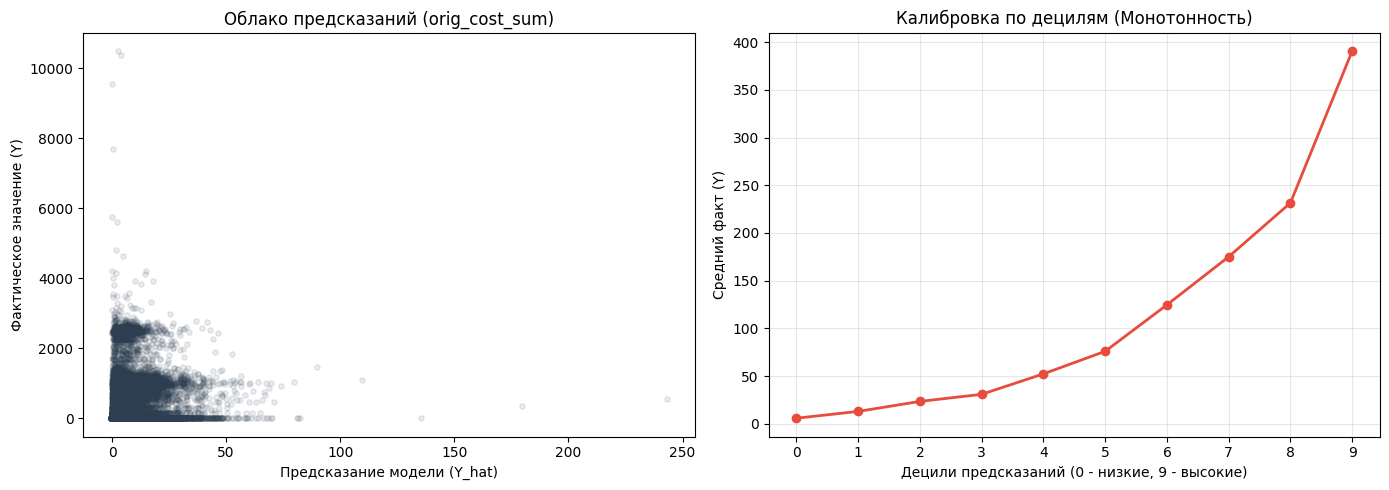

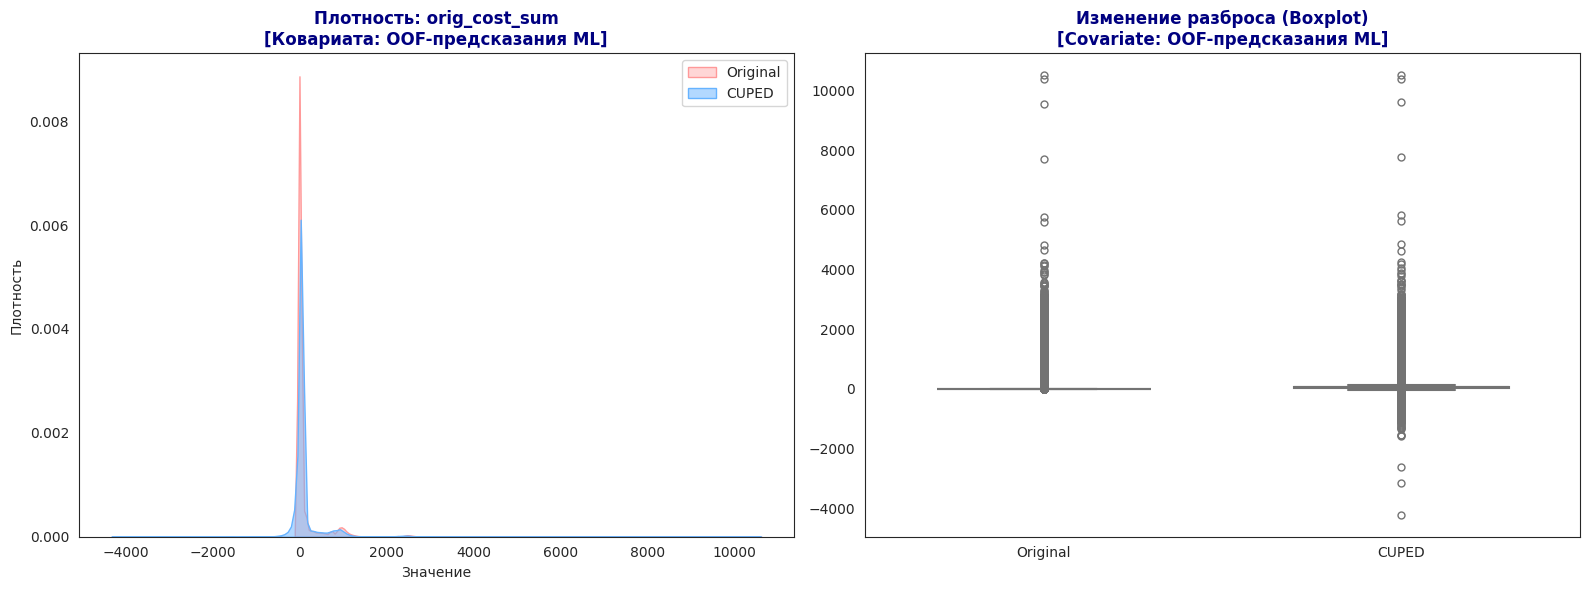


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 ИНТЕРПРЕТАЦИЯ SHAP ДЛЯ ПРЕЗЕНТАЦИИ: orig_cost_sum
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
Вычисление SHAP значений (может занять около минуты)...

[СЛАЙД 1: SUMMARY PLOT]


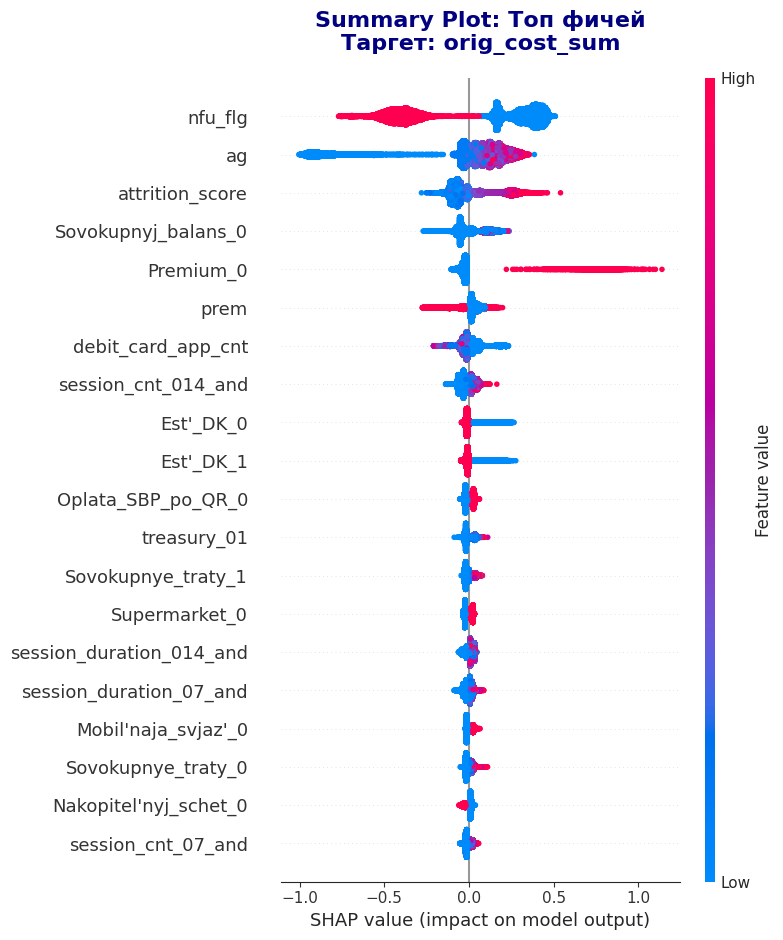


[СЛАЙД 2: DEPENDENCE PLOTS & INTERACTIONS]


<Figure size 800x600 with 0 Axes>

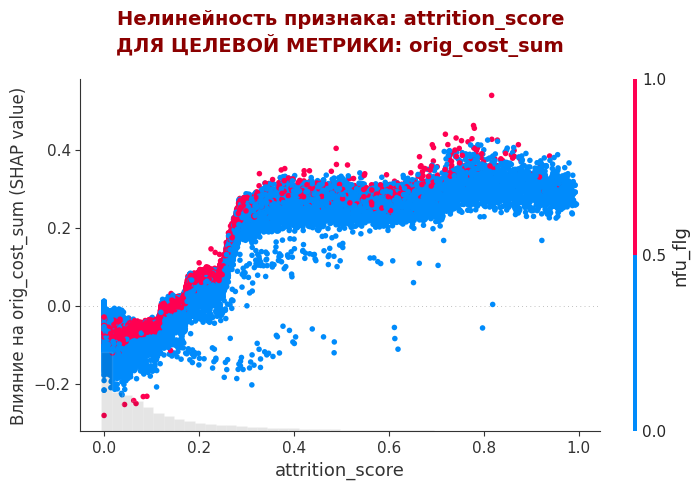


══════════════════════════════════════════════════════════════════════
 ЗАПУСК АНАЛИЗА ДЛЯ МЕТРИКИ: life_1_day_flg
══════════════════════════════════════════════════════════════════════
[life_1_day_flg] Загрузка и очистка данных...
Итоговый размер датасета: (83208, 327)

Тип таргета: БИНАРНЫЙ (Classification)

Запуск 5-Fold Cross-Validation...
  Fold 1/5 завершен (Деревьев: 498)
  Fold 2/5 завершен (Деревьев: 500)
  Fold 3/5 завершен (Деревьев: 500)
  Fold 4/5 завершен (Деревьев: 499)
  Fold 5/5 завершен (Деревьев: 493)

РЕЗУЛЬТАТЫ: CatBoost ML-CUPED (Life 1 Days)
  Корреляция Corr(Y, Y_hat):     0.5474 -> (Ожидаемое снижение ~29.97%)
  Оптимальная Theta (θ):          1.0226
  Дисперсия ДО:                  0.16
  Дисперсия ПОСЛЕ:               0.11
  ФАКТИЧЕСКОЕ СНИЖЕНИЕ VARIANCE: 29.97%


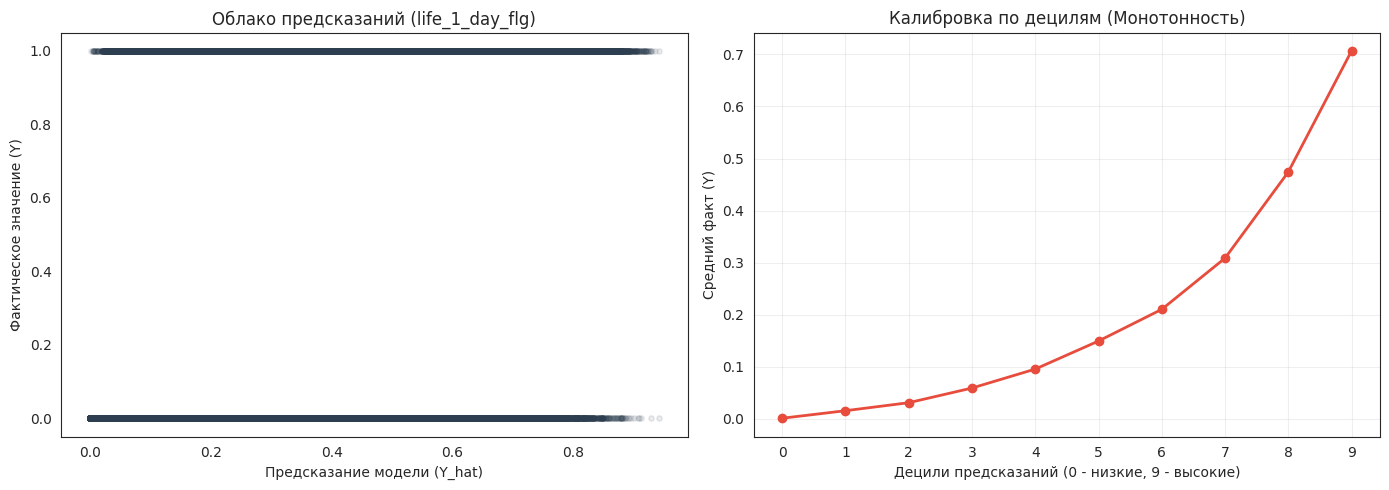

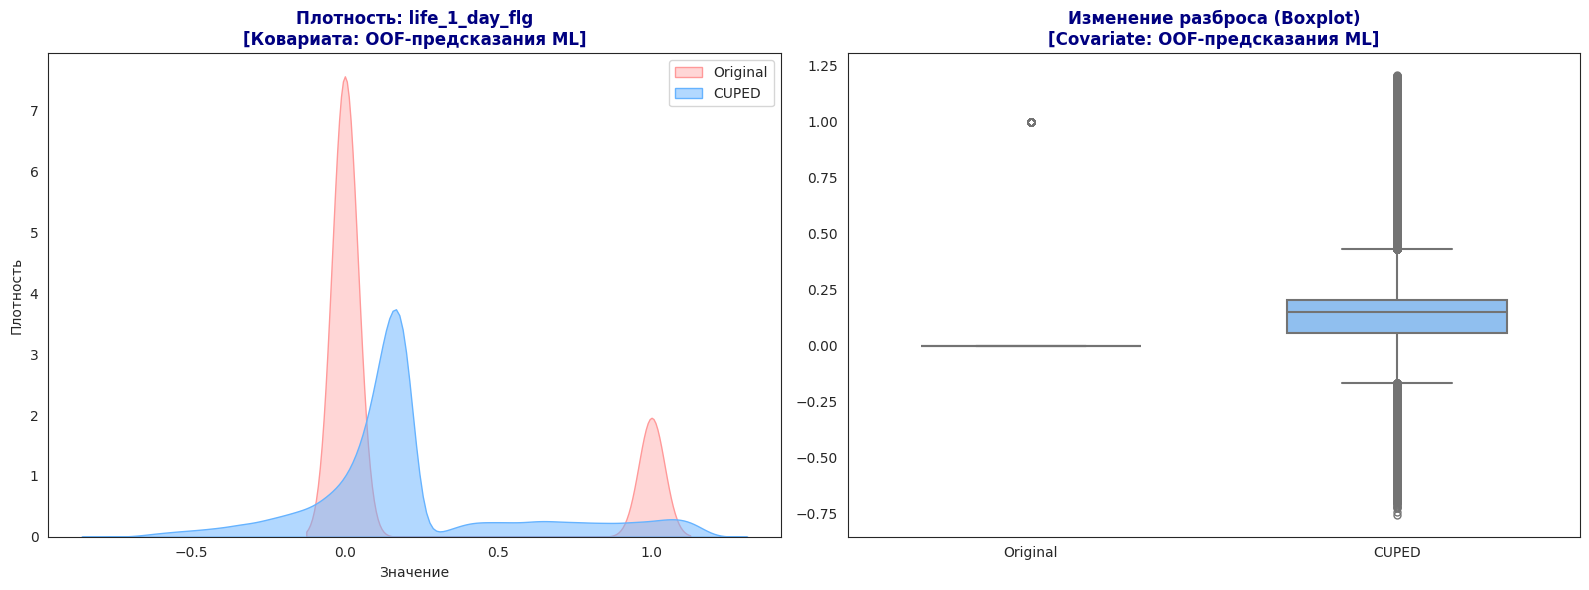


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 ИНТЕРПРЕТАЦИЯ SHAP ДЛЯ ПРЕЗЕНТАЦИИ: life_1_day_flg
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
Вычисление SHAP значений (может занять около минуты)...

[СЛАЙД 1: SUMMARY PLOT]


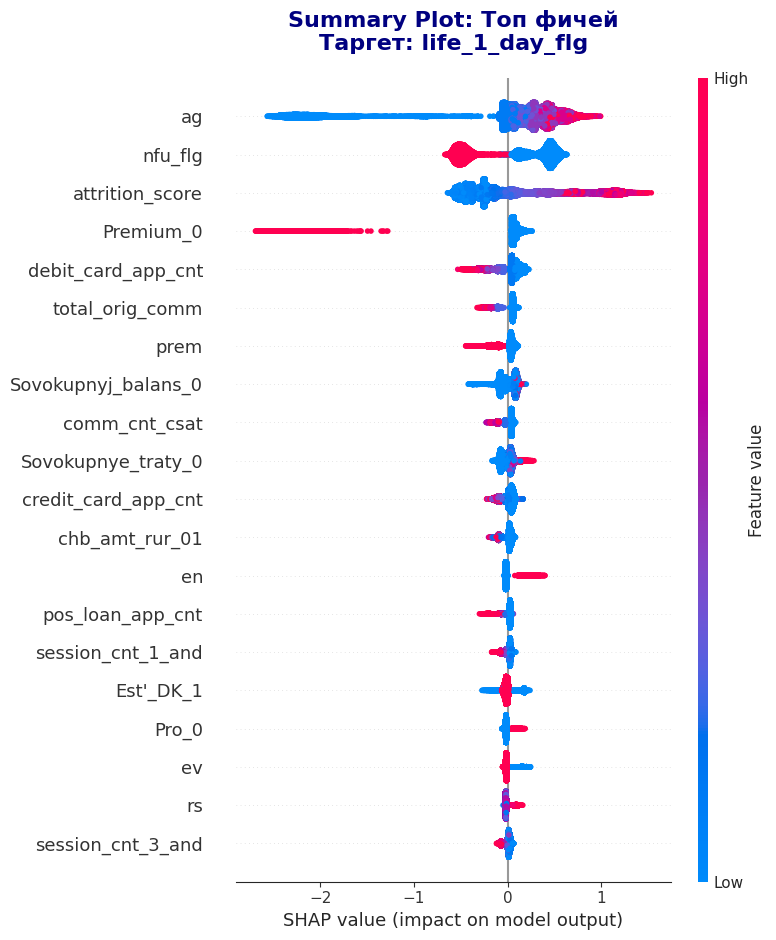


[СЛАЙД 2: DEPENDENCE PLOTS & INTERACTIONS]


<Figure size 800x600 with 0 Axes>

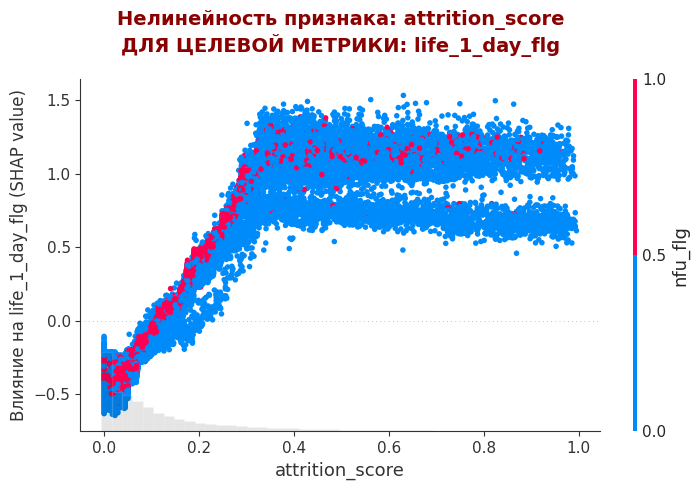


══════════════════════════════════════════════════════════════════════
 ЗАПУСК АНАЛИЗА ДЛЯ МЕТРИКИ: life_32_day_flg
══════════════════════════════════════════════════════════════════════
[life_32_day_flg] Загрузка и очистка данных...
Итоговый размер датасета: (83208, 327)

Тип таргета: БИНАРНЫЙ (Classification)

Запуск 5-Fold Cross-Validation...
  Fold 1/5 завершен (Деревьев: 260)
  Fold 2/5 завершен (Деревьев: 496)
  Fold 3/5 завершен (Деревьев: 335)
  Fold 4/5 завершен (Деревьев: 495)
  Fold 5/5 завершен (Деревьев: 480)

РЕЗУЛЬТАТЫ: CatBoost ML-CUPED (Life 32 Days)
  Корреляция Corr(Y, Y_hat):     0.4873 -> (Ожидаемое снижение ~23.74%)
  Оптимальная Theta (θ):          1.0182
  Дисперсия ДО:                  0.08
  Дисперсия ПОСЛЕ:               0.06
  ФАКТИЧЕСКОЕ СНИЖЕНИЕ VARIANCE: 23.74%


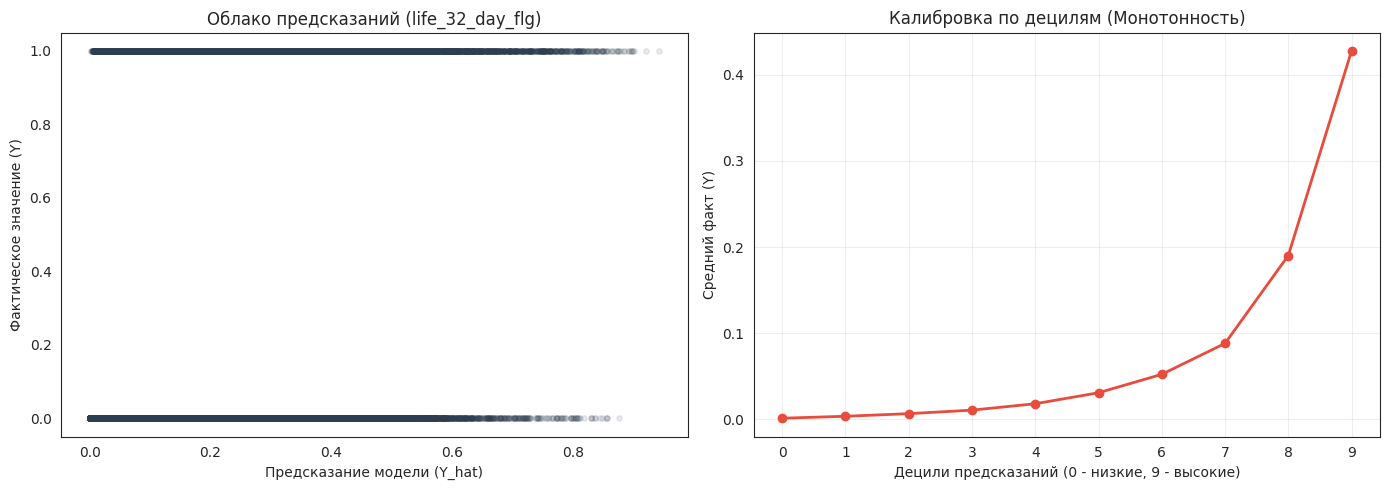

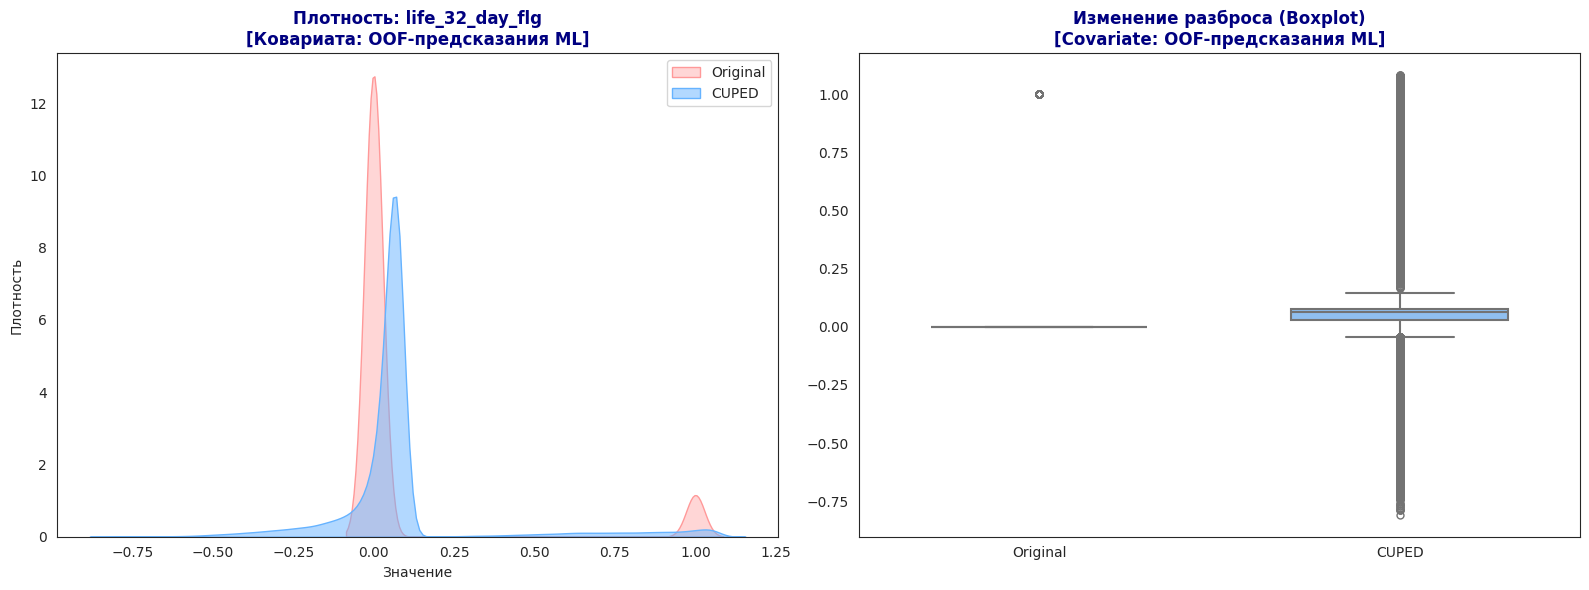


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 ИНТЕРПРЕТАЦИЯ SHAP ДЛЯ ПРЕЗЕНТАЦИИ: life_32_day_flg
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
Вычисление SHAP значений (может занять около минуты)...

[СЛАЙД 1: SUMMARY PLOT]


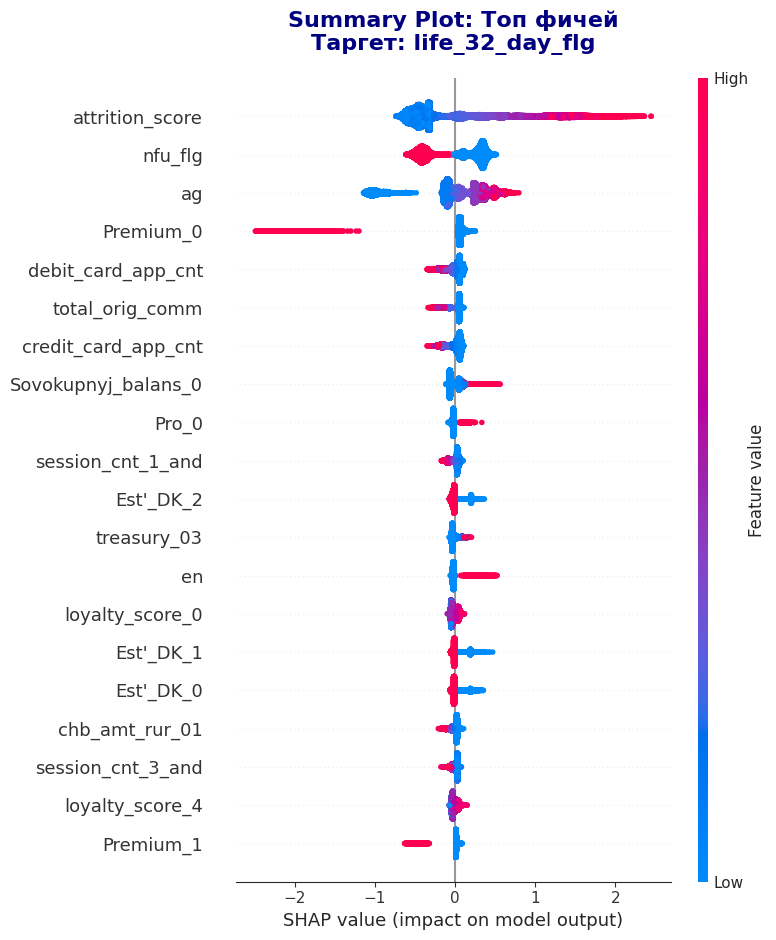


[СЛАЙД 2: DEPENDENCE PLOTS & INTERACTIONS]


<Figure size 800x600 with 0 Axes>

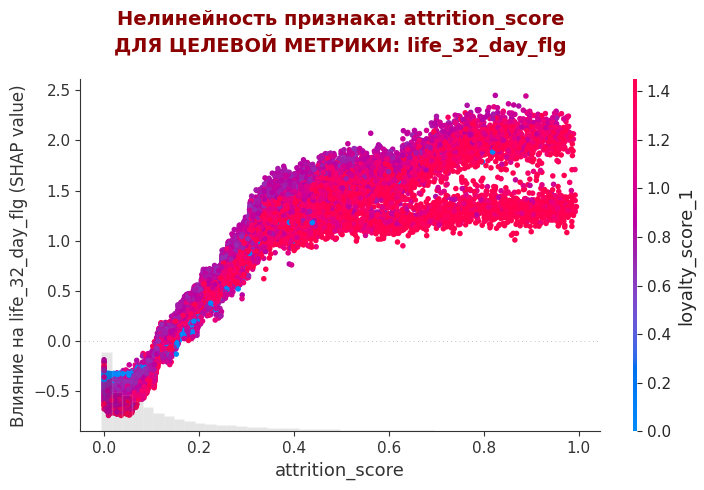


 Анализ завершен!


In [ ]:
# ==========================================
# ЗАПУСК PIPELINE
# ==========================================
DATA_PATH = '/content/drive/MyDrive/курсач/dataset_back.csv'

ALL_TARGETS = ['orig_cost_sum', 'life_1_day_flg', 'life_32_day_flg']
PRETTY_NAMES = {
    'orig_cost_sum': 'CatBoost ML-CUPED (Orig Cost)',
    'life_1_day_flg': 'CatBoost ML-CUPED (Life 1 Days)',
    'life_32_day_flg': 'CatBoost ML-CUPED (Life 32 Days)'
}

results_dict = {}

for target in ALL_TARGETS:
    print("\n" + "═"*70)
    print(f" ЗАПУСК АНАЛИЗА ДЛЯ МЕТРИКИ: {target}")
    print("═"*70)

    other_targets = [t for t in ALL_TARGETS if t != target]
    df_current = load_and_clean_data(DATA_PATH, target_col=target, other_targets=other_targets)

    # 1. Считаем OOF прогнозы
    y_real, oof_cb, is_bin = get_oof_predictions(df_current, target_col=target)

    # 2. Считаем CUPED
    model_name = PRETTY_NAMES.get(target, f"CatBoost ML-CUPED ({target})")
    cuped_cb = calculate_optimal_cuped(y_real, oof_cb, model_name)

    # 3. Графики (ваши старые)
    plot_sanity_checks(y_real, oof_cb, target)
    plot_cuped_variance_reduction(y_real, cuped_cb, target)


    # 4. НОВОЕ: SHAP ИНТЕРПРЕТАЦИЯ (только для непрерывной метрики, чтобы не спамить)
    # обновил код тут

    run_shap_analysis(df_current, target_col=target, is_binary=is_bin)

    results_dict[target] = {'y_real': y_real, 'y_hat': oof_cb, 'y_cuped': cuped_cb}

print("\n Анализ завершен!")